# Thermal Knee Image Preprocessing & Clinical Label Assignment Pipeline

## Executive Summary

This notebook implements a **production-grade, 9-step linear data pipeline** for thermal imaging analysis with strict patient-level data leakage prevention. The pipeline integrates medical image preprocessing (denoising, contrast enhancement, segmentation), clinical label assignment via three-key merging, and leak-proof train/val/test splitting with class-balanced augmentation.

---

## Pipeline Architecture

### Phase 1: Data Ingestion & Quality Control
- **Step 1**: Load clinical baseline data (PN, Visit, side_right, pain_label)
- **Step 2**: Discover raw thermal images and extract anatomical metadata
- **Step 2.1**: Patient ID validation & cross-reference filtering
- **Step 2.2**: Comprehensive raw image exploratory analysis

### Phase 2: Metadata Engineering (Pre-Processing)
- **Step 3**: Extract visit numbers via robust regex; compute capture indices to prevent filename collisions

### Phase 3: Image Enhancement & Preprocessing
- **Step 4**: Apply medical-grade preprocessing:
  - Logo/artifact removal
  - Hair removal via morphological operations
  - Background masking to isolate thermal subject
  - **Hand Fix**: Extract only the largest contour (the knee) to eliminate hands/reflections
  - **Black Screen Fix**: Validate image quality (≥15% visible pixels, ≥60px spatial constraints)
  - **CLAHE**: Contrast-Limited Adaptive Histogram Equalization (clipLimit=2.0, 8×8 tiles) for thermal contrast enhancement
  - Standardized 256×256 resizing

### Phase 4: Clinical Label Assignment
- **Step 5**: Three-key left merge (PN_norm, Visit, side_right) + **strict null filtering** (no imputation)
- Present class imbalance with clear severity assessment

### Phase 5: Leak-Proof Train/Val/Test Splitting & Augmentation
- **Step 6**: Export labeled manifest (all explicitly labeled images)
- **Step 6.5**: Prepare X (image paths), y (pain labels), groups (patient IDs)
- **Step 7**: Patient-level GroupShuffleSplit (70%/10%/20% train/val/test) — zero cross-set patient overlap
- **Step 8**: Offline augmentation (train set only) for minority class balancing
- **Step 9**: Export final three train/val/test manifests

---

## Critical Design Principles

1. **No Data Leakage**: Patient IDs are atomic units; no patient appears in multiple sets
2. **Explicit Labels Only**: Unlabeled images are dropped, not imputed; ground truth integrity is paramount
3. **Safe Augmentation**: Rotation, zoom, brightness adjustments only (NO horizontal flips that violate left/right anatomy)
4. **Medical Image Fidelity**: CLAHE applied to enhance thermal signatures; all preprocessing respects radiological standards

---

**Run cells sequentially from top to bottom. Do not skip or reorder.**

---

## PHASE 1: DATA INGESTION & QUALITY CONTROL

This phase establishes the data foundation by loading clinical records, discovering raw image files, and performing rigorous quality validation before any processing. We ensure image-to-patient traceability and filter out unmatched data early to prevent downstream errors.

### Objectives
- Load clinical baseline data and verify schema
- Discover raw image files and extract anatomical metadata
- Validate patient ID correspondence between imaging and clinical datasets
- Remove images without clinical baseline records (no data orphans)

In [1]:
# ==============================================================================
# CONSOLIDATED IMPORTS - All libraries and modules required for the entire pipeline
# ==============================================================================

# --- Standard Library ---
import pickle
import re
from pathlib import Path
from typing import Optional, Tuple
import random

# --- Data Manipulation & Analysis ---
import pandas as pd
import numpy as np

# --- Computer Vision & Image Processing ---
import cv2
from PIL import Image

# --- Data Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Machine Learning & Splitting ---
from sklearn.model_selection import GroupShuffleSplit

print("✓ All libraries imported successfully")
print(f"  - Data: pandas {pd.__version__}, numpy {np.__version__}")
print(f"  - Vision: OpenCV {cv2.__version__}, Pillow {Image.__version__}")
print(f"  - ML: scikit-learn {__import__('sklearn').__version__}")

✓ All libraries imported successfully
  - Data: pandas 2.3.3, numpy 2.4.0
  - Vision: OpenCV 4.13.0, Pillow 12.1.0
  - ML: scikit-learn 1.8.0


In [2]:
# === STEP 1: LOAD CLINICAL BASELINE DATA ===
#
# This is our source of ground truth for clinical labels.
# We load the pickled checkpoint (created from raw Excel files in prior EDA).
# Verify schema matches expectations before proceeding.

# Load pre-processed clinical data (baseline characteristics + pain labels)
with open('cleaned_tabular_checkpoint.pkl', 'rb') as f:
    df_merged = pickle.load(f)

print(f"Loaded clinical data: {len(df_merged)} patient records")
print(f"Columns: {list(df_merged.columns)}")

# === SCHEMA VALIDATION ===
# Verify that required columns exist for downstream merging
required_columns = ['PN', 'Visit', 'side_right', 'pain_label']
missing_cols = [col for col in required_columns if col not in df_merged.columns]

if missing_cols:
    print(f"ERROR: Missing required columns: {missing_cols}")
else:
    print(f"✓ Schema validated: all required columns present")

# === INSPECT DATA TYPES ===
print(f"\nColumn types:")
for col in required_columns:
    if col in df_merged.columns:
        print(f"  {col:20s}: {df_merged[col].dtype}")

print(f"\n✓ Step 1 complete: Clinical baseline data loaded")
display(df_merged.head(10))

Loaded clinical data: 432 patient records
Columns: ['PN', 'PC', 'INCLUDED', 'GROUP', 'DOCTOR', 'QUALITY', 'PF_DIAGNOSIS', 'Visit', 'AKP', 'Ant_3', 'Ant_5', 'Ant_6', 'Ant_7', 'Ant_9', 'Lateral', 'Medial', 'Pat', 'Ext', 'תאריך', 'Worst', 'Average', 'side_right', 'male', 'pain_label']
✓ Schema validated: all required columns present

Column types:
  PN                  : object
  Visit               : int64
  side_right          : int64
  pain_label          : int64

✓ Step 1 complete: Clinical baseline data loaded


,PN,PC,INCLUDED,GROUP,DOCTOR,QUALITY,PF_DIAGNOSIS,Visit,AKP,Ant_3,...,Lateral,Medial,Pat,Ext,תאריך,Worst,Average,side_right,male,pain_label
0,MC-02,2,0,1.0,Spizer,1.0,1,1,1,1,...,1,0,0,1,27.03.17,70.0,53,1,1,1
1,MC-02,2,0,1.0,Spizer,1.0,1,1,1,1,...,0,0,1,0,27.03.17,46.0,53.0,0,1,1
2,AB-03,3,0,2.0,Barzilay,1.0,1,1,0,0,...,0,0,0,0,3.05.17,0.0,0,1,1,0
3,AB-03,3,0,2.0,Barzilay,1.0,1,1,1,0,...,0,1,0,0,3.05.17,66.0,39.0,0,1,1
4,YE-04,4,0,2.0,Barzilay,1.0,1,1,0,0,...,0,0,0,0,8.05.17,0.0,0,1,1,0
5,YE-04,4,0,2.0,Barzilay,1.0,1,1,1,0,...,0,0,1,0,8.05.17,99.0,66.0,0,1,1
6,AP-05,5,0,1.0,Friedman,1.0,1,1,1,0,...,0,1,0,0,8.05.17,82.0,58,1,1,1
7,AP-05,5,0,1.0,Friedman,1.0,1,1,0,0,...,0,0,0,0,8.05.17,0.0,0.0,0,1,0
8,CH-07,7,0,2.0,Friedman,1.0,1,1,0,0,...,0,0,0,0,25.05.17,27.0,13,1,1,0
9,CH-07,7,0,2.0,Friedman,1.0,1,1,1,0,...,0,1,0,0,25.05.17,62.0,56.0,0,1,1


---

### Step 2: Image Discovery & Metadata Extraction

**Objective**: Perform filesystem traversal to locate all raw thermal images and extract intrinsic metadata (dimensions, anatomical region, body side).

**Methodology**: 
- Recursive directory walk through `Images/` to discover all image files (JPEG, PNG, BMP, TIFF formats)
- Extract subject ID from folder hierarchy
- Apply heuristic rules to infer anatomical region (ANT/POST/LAT/MED) and body side (L/R) from path components
- Record raw dimensions (width, height) for downstream analysis

**Expected Outcome**: A structured manifest with N raw images, each with standardized anatomical labels and dimensional metadata, ready for quality assessment.

In [3]:
# === STEP 2: DISCOVER RAW IMAGES AND EXTRACT METADATA ===
#
# Walk the Images/ directory tree to find all raw thermal images.
# Extract metadata directly from file paths:
#   - Subject ID from folder name (e.g., "10-TA" → subject="10-TA")
#   - Anatomical region inferred from heuristics (ANT/POST/LAT/MED)
#   - Body side inferred from file name (L/R or context)
#   - Raw image dimensions for downstream analysis

# Create manifest of all raw images
records = []
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}
base_dir = Path('Images')

print(f"Scanning {base_dir} for thermal images...")

for subject_dir in sorted(base_dir.iterdir()):
    if not subject_dir.is_dir():
        continue
    
    subject = subject_dir.name  # e.g., "10-TA"
    
    # Walk all subdirectories (may be nested)
    for img_path in subject_dir.rglob('*'):
        if not img_path.is_file():
            continue
        
        # Filter by image extension
        if img_path.suffix.lower() not in image_extensions:
            continue
        
        try:
            # Load image to get dimensions (and verify it's a valid image)
            img_bgr = cv2.imread(str(img_path))
            if img_bgr is None:
                continue
            
            height, width = img_bgr.shape[:2]
        except Exception:
            continue
        
        # Extract region and side from file path components
        # Example path: Images/10-TA/ANT/image_L.jpg
        path_parts = img_path.relative_to(base_dir).parts
        file_name = img_path.name
        
        # Infer anatomical region from path components
        region = None
        for part in path_parts:
            part_upper = part.upper()
            if part_upper in ['ANT', 'POST', 'LAT', 'MED']:
                region = part_upper
                break
        
        if not region:
            # If not in path, try to infer from filename
            file_lower = file_name.lower()
            for r in ['ant', 'post', 'lat', 'med']:
                if r in file_lower:
                    region = r.upper()
                    break
        
        if not region:
            region = 'UNKNOWN'
        
        # Infer body side from filename
        side = None
        file_lower = file_name.lower()
        for marker, side_val in [('_l', 'L'), ('_r', 'R'), ('left', 'L'), ('right', 'R')]:
            if marker in file_lower:
                side = side_val
                break
        
        if not side:
            side = ''
        
        records.append({
            'subject': subject,
            'file_name': file_name,
            'file_path': str(img_path),
            'region': region,
            'side': side,
            'width': width,
            'height': height,
        })

# Create manifest DataFrame
source_manifest = pd.DataFrame(records)

print(f"\n✓ Step 2 complete: Image discovery finished")
print(f"  Total images found: {len(source_manifest)}")
print(f"  Regions: {source_manifest['region'].value_counts().to_dict()}")
print(f"  Sides: {source_manifest['side'].value_counts().to_dict()}")

display(source_manifest.head(15))

Scanning Images for thermal images...

✓ Step 2 complete: Image discovery finished
  Total images found: 1607
  Regions: {'ANT': 490, 'MED': 339, 'POST': 289, 'LAT': 259, 'UNKNOWN': 230}
  Sides: {'': 682, 'L': 587, 'R': 338}


,subject,file_name,file_path,region,side,width,height
0,10-TA,10-TA Scale.JPG,Images/10-TA/10-TA Scale.JPG,UNKNOWN,,732,503
1,10-TA,10TA-11jan18_EndTrial_3Ant-Left.tiff,Images/10-TA/FU3/Ant/10TA-11jan18_EndTrial_3An...,ANT,L,653,490
2,10-TA,10TA-11jan18_EndTrial_3Ant-Right.tiff,Images/10-TA/FU3/Ant/10TA-11jan18_EndTrial_3An...,ANT,R,653,490
3,10-TA,10TA-11jan18_EndTrial_1Ant.tiff,Images/10-TA/FU3/Ant/10TA-11jan18_EndTrial_1An...,ANT,,653,490
4,10-TA,10TA-11jan18_EndTrial_1Post.tiff,Images/10-TA/FU3/Post/10TA-11jan18_EndTrial_1P...,POST,,653,490
5,10-TA,10TA-11jan18_EndTrial_2Lat-Left.tiff,Images/10-TA/FU3/L/Let/10TA-11jan18_EndTrial_2...,LAT,L,653,490
6,10-TA,10TA-11jan18_EndTrial_2Med-Left.tiff,Images/10-TA/FU3/L/Med/10TA-11jan18_EndTrial_2...,MED,L,653,490
7,10-TA,10TA-11jan18_EndTrial_2Lat-Right.tiff,Images/10-TA/FU3/R/Let/10TA-11jan18_EndTrial_2...,LAT,R,653,490
8,10-TA,10TA-11jan18_EndTrial_2Med-Right.tiff,Images/10-TA/FU3/R/Med/10TA-11jan18_EndTrial_2...,MED,R,653,490
9,10-TA,10TA-21aug17_Baseline_1Ant.tiff,Images/10-TA/Baseline/Ant/10TA-21aug17_Baselin...,ANT,,653,490


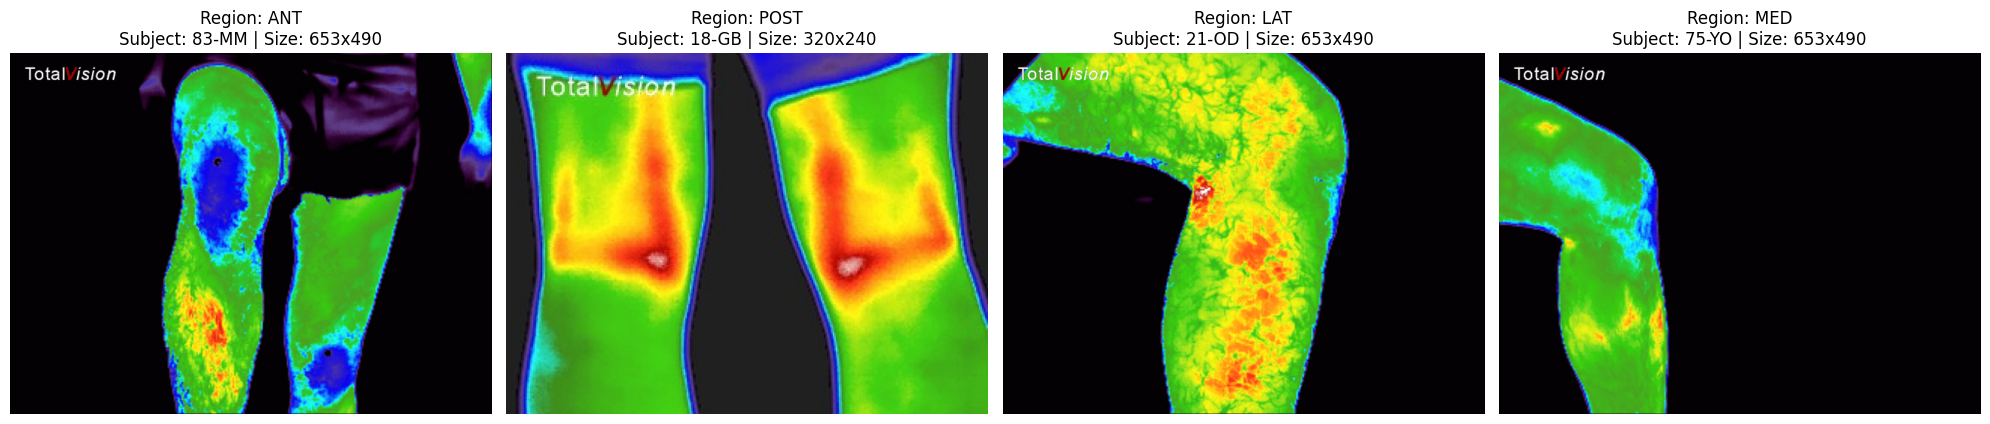

In [4]:
# === VISUAL SANITY CHECK: DISPLAY ONE IMAGE PER TARGET REGION ===
#
# Randomly sample exactly one image from each of the four primary anatomical 
# regions (Anterior, Posterior, Lateral, Medial) to visually verify the dataset's 
# diversity, confirm orientation differences, and ensure images load correctly.

# Define the specific four regions we want to visualize
target_regions = ['ANT', 'POST', 'LAT', 'MED']
num_regions = len(target_regions)

# Create a 1x4 grid for the images
fig, axes = plt.subplots(1, num_regions, figsize=(5 * num_regions, 5))

for ax, region in zip(axes, target_regions):
    # Filter the manifest for the specific region
    region_df = source_manifest[source_manifest['region'] == region]
    
    if not region_df.empty:
        # Sample exactly one row for the current region
        sample_row = region_df.sample(n=1, random_state=42).iloc[0]
        
        # OpenCV loads images in BGR format; convert to RGB for accurate matplotlib display
        img_bgr = cv2.imread(sample_row['file_path'])
        
        if img_bgr is not None:
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            ax.imshow(img_rgb)
            # Display the region prominently along with subject ID and dimensions
            ax.set_title(f"Region: {region}\nSubject: {sample_row['subject']} | Size: {sample_row['width']}x{sample_row['height']}")
        else:
            ax.text(0.5, 0.5, 'Image Load Failed', ha='center', va='center')
            ax.set_title(f"Region: {region}")
    else:
        # Handle case where a region might be entirely missing from the dataset
        ax.text(0.5, 0.5, f'No {region} Images', ha='center', va='center')
        ax.set_title(f"Region: {region}")
        
    ax.axis('off')

plt.tight_layout()
plt.show()

---

### Step 2.1: Patient ID Validation & Cross-Reference Filtering

**Objective**: Ensure all discovered images have corresponding clinical baseline records, eliminating orphan images before processing.

**Methodology**: 
- Normalize patient IDs (PN) from both image filesystem (folder names) and Excel clinical data using consistent regex rules
- Compute overlap: images ∩ clinical records
- Identify images belonging to patients not in the clinical dataset (data orphans)

**Expected Outcome**: 
- Filtered image manifest containing only images from patients with clinical records
- Summary statistics showing how many images were excluded due to missing clinical baselines

In [5]:
# === STEP 2.1: VALIDATE PATIENT ID CORRESPONDENCE & FILTER ORPHANS ===
#
# The clinical dataset (Excel) and the image filesystem use different patient ID formats.
# We normalize both using consistent rules, then check overlap.
# Any image belonging to a patient NOT in the clinical data is an orphan — we drop it.

# === NORMALIZATION FUNCTION ===
def normalize_pn(value):
    """
    Normalize patient IDs to canonical format for cross-dataset matching.
    
    Handles variations:
    - "TA-10" → "TA-10" (already standard)
    - "10-TA" → "TA-10" (reordered from Number-Letter to Letter-Number)
    - "TA_10", "TA 10" → "TA-10" (punctuation normalized to dash)
    - "ta10" → "TA-10" (case and formatting normalized)
    
    Returns pd.NA if input is NaN (preserves missingness through merge operations).
    
    Why normalization matters:
    - Excel files might have "10-TA", but folder names are "TA-10"
    - Without normalization, merge would fail and all images would be marked as orphans
    - Canonical format ensures correct clinical label assignment
    """
    if pd.isna(value):
        return pd.NA
    
    text = str(value).strip().upper().replace('_', '-').replace(' ', '')
    text = re.sub(r'[^A-Z0-9-]', '', text)
    
    # Reorder if in "Number-Letter" format (e.g., "10-TA" → "TA-10")
    num_first = re.match(r'^(\d{1,3})-([A-Z]{1,4})$', text)
    if num_first:
        return f"{num_first.group(2)}-{num_first.group(1).zfill(2)}"
    
    return text


# === CHECK OVERLAP ===
# Normalize patient IDs in both datasets

source_pn_list = source_manifest['subject'].apply(normalize_pn).unique()
source_pn_set = set(pd.Series(source_pn_list).dropna())
print(f"Unique patients in Images/: {len(source_pn_set)}")
print(f"  Examples: {sorted(list(source_pn_set))[:5]}")

# Clinical data might have different column name (PN, patient_id, etc.)
# Try to find the patient ID column
pn_col = None
for col in ['PN', 'patient_id', 'patient', 'PN_norm']:
    if col in df_merged.columns:
        pn_col = col
        break

if pn_col is None:
    print(f"ERROR: Cannot find patient ID column in clinical data")
    print(f"Available columns: {list(df_merged.columns)}")
else:
    clinical_pn_list = df_merged[pn_col].apply(normalize_pn).unique()
    clinical_pn_set = set(pd.Series(clinical_pn_list).dropna())
    print(f"Unique patients in clinical data: {len(clinical_pn_set)}")
    print(f"  Examples: {sorted(list(clinical_pn_set))[:5]}")
    
    # Calculate overlap
    overlap = source_pn_set & clinical_pn_set
    missing_from_excel = source_pn_set - clinical_pn_set
    
    print(f"\n✓ Overlap: {len(overlap)} patients in both datasets")
    print(f"  Orphan images (no clinical record): {len(missing_from_excel)} patient groups")
    
    if len(missing_from_excel) > 0:
        print(f"  Orphan patient IDs: {sorted(list(missing_from_excel))[:10]}")
    
    # Filter out images from patients not in clinical data
    source_manifest['PN_temp'] = source_manifest['subject'].apply(normalize_pn)
    source_manifest = source_manifest[source_manifest['PN_temp'].isin(overlap)].reset_index(drop=True)
    source_manifest = source_manifest.drop('PN_temp', axis=1)
    
    print(f"\n✓ After filtering orphans: {len(source_manifest)} images remain")
    print(f"  (Started with {len(pd.DataFrame(records))}, dropped {len(pd.DataFrame(records)) - len(source_manifest)})")

print(f"\n✓ Step 2.1 complete: Cross-reference validation finished")

Unique patients in Images/: 72
  Examples: ['AA-77', 'AB-13', 'ABY-36', 'AF-39', 'AF-47']
Unique patients in clinical data: 76
  Examples: ['AA-01', 'AB-03', 'AB-13', 'ABY-36', 'AF-39']

✓ Overlap: 65 patients in both datasets
  Orphan images (no clinical record): 7 patient groups
  Orphan patient IDs: ['AA-77', 'AK-41', 'EA-84', 'EB-70', 'LD-24', 'SB-12', 'TD-79']

✓ After filtering orphans: 1452 images remain
  (Started with 1607, dropped 155)

✓ Step 2.1 complete: Cross-reference validation finished


---

### Step 2.2: Raw Image Exploratory Data Analysis (EDA)

**Objective**: Characterize the raw image dataset across all dimensions: anatomical region distribution, raw pixel dimensions, and brightness distribution.

**Methodology**: 
- **Process ALL images** (not samples) to compute exact population statistics
- Calculate comprehensive statistics for image widths, heights, aspect ratios, and pixel brightness
- Generate 4-panel visualization dashboard showing histograms and statistical summaries

**Why This Matters**: 
- Understanding raw dimension distributions informs preprocessing decisions (e.g., rescaling strategy)
- Brightness analysis reveals thermal contrast characteristics of the imaging protocol
- Region distribution confirms expected anatomical coverage

**Expected Outcome**: 
- Statistical summary table (mean, median, min, max, std for dimensions)
- Visualization dashboard for stakeholder communication
- Insights into preprocessing requirements and potential edge cases

RAW IMAGE EXPLORATORY DATA ANALYSIS

1. Images per anatomical region:
region
ANT        443
LAT        230
MED        304
POST       267
UNKNOWN    208
Name: count, dtype: int64


/var/folders/h_/16c762vj27d0_xht2_6h85z40000gn/T/ipykernel_91746/338356641.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=source_manifest, x='region', ax=ax, palette='Set2', order=['ANT', 'POST', 'LAT', 'MED'])


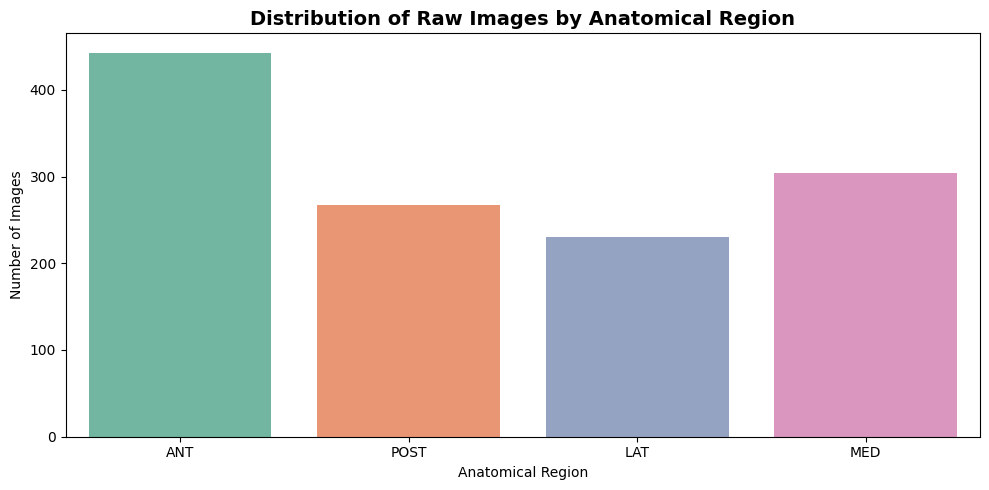


2. Processing ALL raw image dimensions...
  Processed 100/1452 images...
  Processed 200/1452 images...
  Processed 300/1452 images...
  Processed 400/1452 images...
  Processed 500/1452 images...
  Processed 600/1452 images...
  Processed 700/1452 images...
  Processed 800/1452 images...
  Processed 900/1452 images...
  Processed 1000/1452 images...
  Processed 1100/1452 images...
  Processed 1200/1452 images...
  Processed 1300/1452 images...
  Processed 1400/1452 images...
✓ Successfully read dimensions from 1452 images

COMPREHENSIVE DIMENSION STATISTICS (ALL IMAGES)

Image Width:
  Mean:   574.83
  Median: 653.00
  Min:    320
  Max:    739
  Std:    146.03

Image Height:
  Mean:   429.17
  Median: 490.00
  Min:    240
  Max:    521
  Std:    107.65

Aspect Ratio (Width/Height):
  Mean:   1.338
  Median: 1.333
  Min:    0.942
  Max:    1.504
  Std:    0.030

Most common raw image sizes (from 1452 images):
  653x490: 1032 images
  320x240: 354 images
  731x491: 3 images
  736x496:

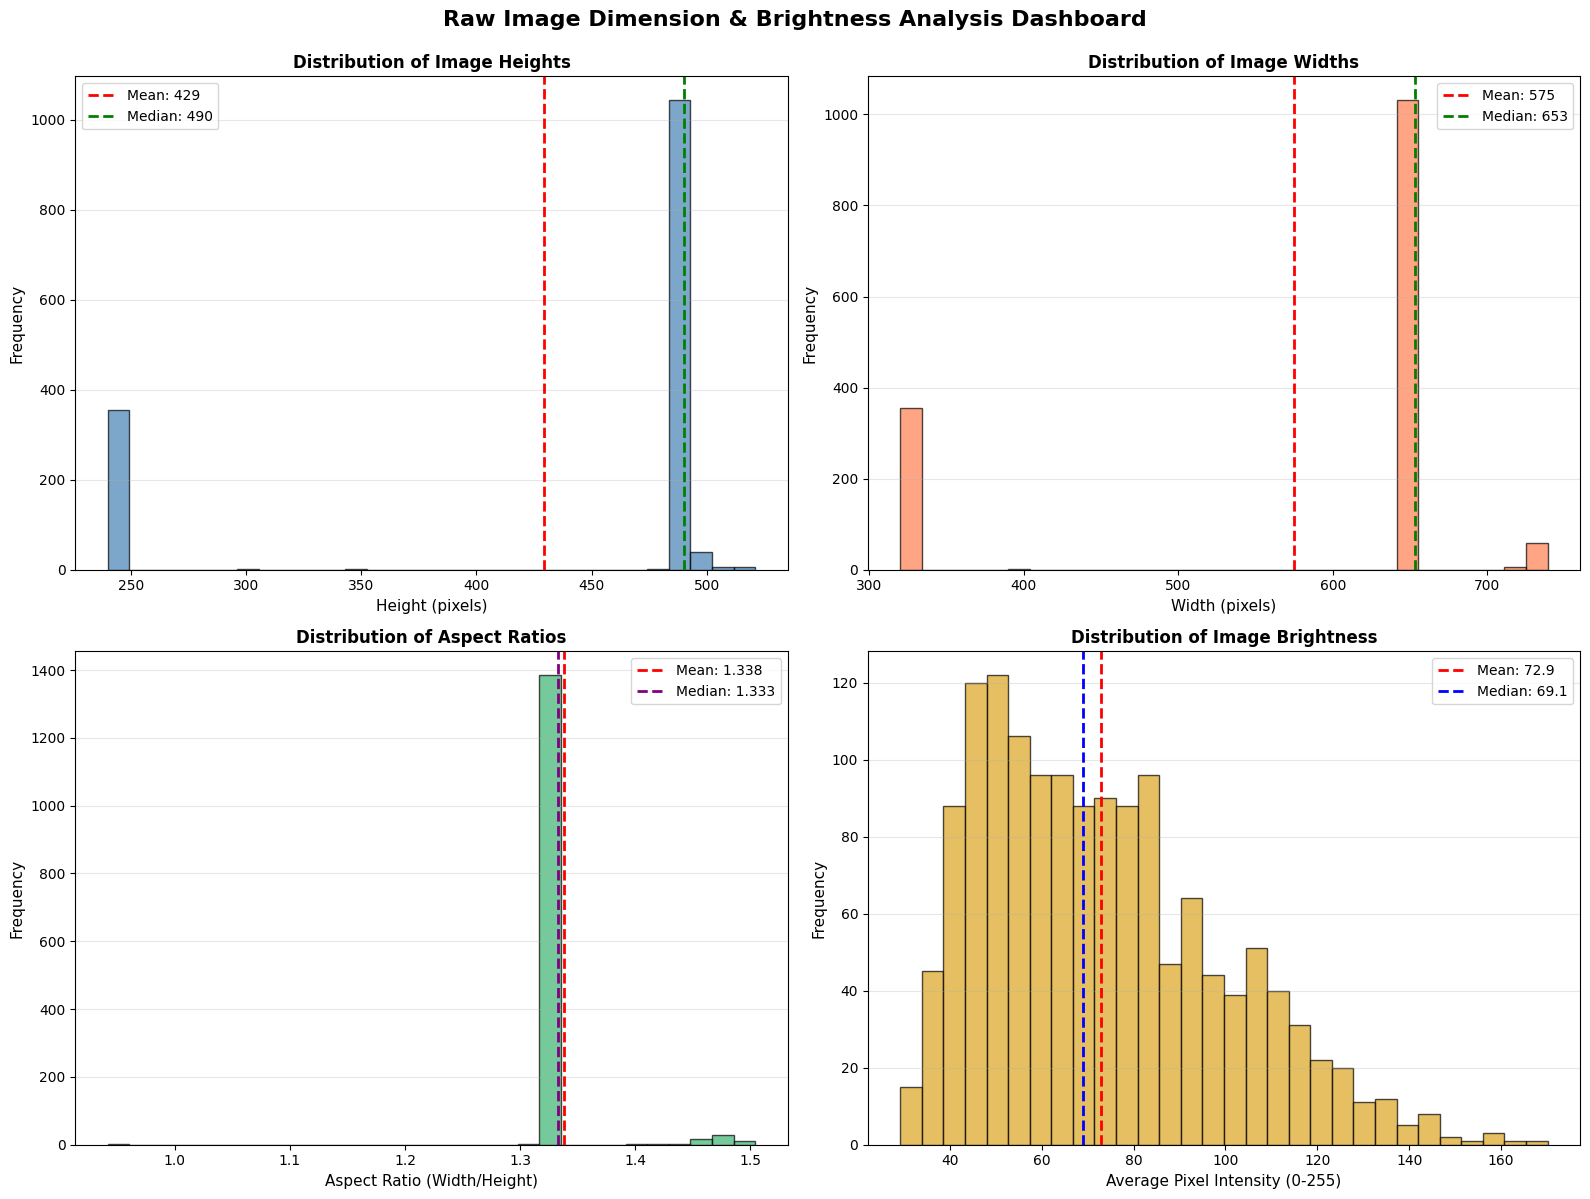


✓ Step 2.2 complete: Comprehensive raw image EDA done


In [6]:
# EDA on the filtered source_manifest
print("="*70)
print("RAW IMAGE EXPLORATORY DATA ANALYSIS")
print("="*70)

# 1. Count images per region
print("\n1. Images per anatomical region:")
region_counts = source_manifest['region'].value_counts().sort_index()
print(region_counts)

# 2. Visualization
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=source_manifest, x='region', ax=ax, palette='Set2', order=['ANT', 'POST', 'LAT', 'MED'])
ax.set_title('Distribution of Raw Images by Anatomical Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Anatomical Region')
ax.set_ylabel('Number of Images')
plt.tight_layout()
plt.show()

# 3. PROCESS ALL IMAGES - Read dimensions for every single raw image
print("\n2. Processing ALL raw image dimensions...")
image_sizes = []
brightness_values = []

for idx, row in source_manifest.iterrows():
    source_path = Path(row['file_path'])
    if not source_path.exists():
        continue
    
    try:
        # Load image and get dimensions
        with Image.open(source_path) as img:
            width, height = img.size
            image_sizes.append((width, height))
        
        # Calculate brightness (average pixel intensity)
        img_bgr = cv2.imread(str(source_path))
        if img_bgr is not None:
            gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
            avg_brightness = np.mean(gray)
            brightness_values.append(avg_brightness)
    except Exception as e:
        pass
    
    if (idx + 1) % 100 == 0:
        print(f"  Processed {idx + 1}/{len(source_manifest)} images...")

print(f"✓ Successfully read dimensions from {len(image_sizes)} images")

# === STATISTICAL SUMMARY ===
if image_sizes:
    size_df = pd.DataFrame(image_sizes, columns=['width', 'height'])
    size_df['aspect_ratio'] = size_df['width'] / size_df['height']
    
    print(f"\n" + "="*70)
    print("COMPREHENSIVE DIMENSION STATISTICS (ALL IMAGES)")
    print("="*70)
    
    # Width statistics
    print(f"\nImage Width:")
    print(f"  Mean:   {size_df['width'].mean():.2f}")
    print(f"  Median: {size_df['width'].median():.2f}")
    print(f"  Min:    {size_df['width'].min()}")
    print(f"  Max:    {size_df['width'].max()}")
    print(f"  Std:    {size_df['width'].std():.2f}")
    
    # Height statistics
    print(f"\nImage Height:")
    print(f"  Mean:   {size_df['height'].mean():.2f}")
    print(f"  Median: {size_df['height'].median():.2f}")
    print(f"  Min:    {size_df['height'].min()}")
    print(f"  Max:    {size_df['height'].max()}")
    print(f"  Std:    {size_df['height'].std():.2f}")
    
    # Aspect ratio statistics
    print(f"\nAspect Ratio (Width/Height):")
    print(f"  Mean:   {size_df['aspect_ratio'].mean():.3f}")
    print(f"  Median: {size_df['aspect_ratio'].median():.3f}")
    print(f"  Min:    {size_df['aspect_ratio'].min():.3f}")
    print(f"  Max:    {size_df['aspect_ratio'].max():.3f}")
    print(f"  Std:    {size_df['aspect_ratio'].std():.3f}")
    
    # Most common sizes
    print(f"\nMost common raw image sizes (from {len(image_sizes)} images):")
    common_sizes = size_df[['width', 'height']].value_counts().head(10)
    for (w, h), count in common_sizes.items():
        print(f"  {int(w)}x{int(h)}: {count} images")

# === VISUALIZATION DASHBOARD ===
if image_sizes:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Raw Image Dimension & Brightness Analysis Dashboard', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    # 1. Image Height Distribution
    ax1 = axes[0, 0]
    ax1.hist(size_df['height'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax1.axvline(size_df['height'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {size_df['height'].mean():.0f}")
    ax1.axvline(size_df['height'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {size_df['height'].median():.0f}")
    ax1.set_xlabel('Height (pixels)', fontsize=11)
    ax1.set_ylabel('Frequency', fontsize=11)
    ax1.set_title('Distribution of Image Heights', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # 2. Image Width Distribution
    ax2 = axes[0, 1]
    ax2.hist(size_df['width'], bins=30, color='coral', edgecolor='black', alpha=0.7)
    ax2.axvline(size_df['width'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {size_df['width'].mean():.0f}")
    ax2.axvline(size_df['width'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {size_df['width'].median():.0f}")
    ax2.set_xlabel('Width (pixels)', fontsize=11)
    ax2.set_ylabel('Frequency', fontsize=11)
    ax2.set_title('Distribution of Image Widths', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    # 3. Aspect Ratio Distribution
    ax3 = axes[1, 0]
    ax3.hist(size_df['aspect_ratio'], bins=30, color='mediumseagreen', edgecolor='black', alpha=0.7)
    ax3.axvline(size_df['aspect_ratio'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {size_df['aspect_ratio'].mean():.3f}")
    ax3.axvline(size_df['aspect_ratio'].median(), color='purple', linestyle='--', linewidth=2, label=f"Median: {size_df['aspect_ratio'].median():.3f}")
    ax3.set_xlabel('Aspect Ratio (Width/Height)', fontsize=11)
    ax3.set_ylabel('Frequency', fontsize=11)
    ax3.set_title('Distribution of Aspect Ratios', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)
    
    # 4. Brightness Distribution (from sample if all processed, otherwise from collected values)
    ax4 = axes[1, 1]
    if brightness_values:
        ax4.hist(brightness_values, bins=30, color='goldenrod', edgecolor='black', alpha=0.7)
        ax4.axvline(np.mean(brightness_values), color='red', linestyle='--', linewidth=2, label=f"Mean: {np.mean(brightness_values):.1f}")
        ax4.axvline(np.median(brightness_values), color='blue', linestyle='--', linewidth=2, label=f"Median: {np.median(brightness_values):.1f}")
        ax4.set_xlabel('Average Pixel Intensity (0-255)', fontsize=11)
        ax4.set_ylabel('Frequency', fontsize=11)
        ax4.set_title('Distribution of Image Brightness', fontsize=12, fontweight='bold')
        ax4.legend()
        ax4.grid(axis='y', alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'Brightness data not available', 
                ha='center', va='center', fontsize=12, transform=ax4.transAxes)
        ax4.set_title('Distribution of Image Brightness', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

print(f"\n✓ Step 2.2 complete: Comprehensive raw image EDA done")

---

## PHASE 2: METADATA ENGINEERING (BEFORE PROCESSING)

Extract and structure high-level metadata directly from raw file manifests before undertaking computationally expensive preprocessing. This allows us to catch labeling errors early and build indexed data structures for efficient downstream retrieval.

### Step 3: Visit Number Extraction & Capture Index Computation

**Objective**: 
- Assign visit numbers (V1=baseline, V2=FU1, V3=FU3) via robust text matching on file paths
- Create per-(PN, Visit, Region) capture indices to handle multiple images of the same anatomical site

**Methodology**: 
- Apply regex-based visit extraction with known variants (e.g., "baseline", "fu 1", "v0")
- Drop images with unmappable visit numbers (data integrity check)
- Group by (PN_norm, Visit, region) and compute capture_index = cumulative count
- This prevents filename collisions if a patient has multiple captures of the same region at the same visit

**Why This Matters**: 
- Visit numbers are critical for merging with clinical data (pain scores are recorded per-visit)
- Capture indices enable exact traceability: PN_V1_ANT_C1 refers to patient PN's first baseline ANT capture
- Prevents silent data overwrites during preprocessing

**Expected Outcome**: 
- source_manifest with Visit and capture_index columns added
- All rows with unmapped visits removed (data quality checkpoint)

In [7]:
def normalize_pn(value):
    """
    Normalize patient IDs to a canonical format for consistent merging across datasets.
    
    Handles variations in patient ID formatting:
    - "TA-10" → "TA-10" (already standard)
    - "10-TA" → "TA-10" (reordered to standard Letter-Number format)
    - "TA_10", "TA 10", "ta10" → all normalized to "TA-10"
    
    Returns pd.NA if input is NaN (propagates missingness through merge operations).
    """
    if pd.isna(value):
        return pd.NA
    
    # Clean and uppercase
    text = str(value).strip().upper().replace('_', '-').replace(' ', '')
    # Remove any non-alphanumeric or dash characters
    text = re.sub(r'[^A-Z0-9-]', '', text)
    
    # Reorder if patient ID is in "Number-Letter" format (e.g., "10-TA" → "TA-10")
    num_first = re.match(r'^(\d{1,3})-([A-Z]{1,4})$', text)
    if num_first:
        return f"{num_first.group(2)}-{num_first.group(1).zfill(2)}"
    
    return text


def extract_visit_number(file_path, file_name):
    """
    Extract visit number from file path/name using domain-specific heuristics.
    
    Maps text patterns to visit integers:
    - Visit 1 (baseline): keywords ['baseline', 'base', 'visit 0', 'v0']
    - Visit 2 (follow-up 1): keywords ['fu 1', 'fu1', 'visit 1', 'v1']
    - Visit 3 (follow-up 3): keywords ['fu 3', 'fu3', 'visit 3', 'v3']
    
    Returns pd.NA if no pattern matches. These unmatched images are dropped in the next step
    to ensure we only process images with known visit assignments.
    
    This is critical because clinical pain_label scores are recorded per-visit, and we must
    match images to the correct visit's pain score.
    """
    text = f"{file_path} {file_name}".lower()

    visit_map = {
        1: ['baseline', 'base', 'visit 0', 'visit0', 'v0'],
        2: ['fu 1', 'fu1', 'fu-1', 'f1', 'visit 1', 'visit1', 'v1', 'follow.up.1'],
        3: ['fu 3', 'fu3', 'fu-3', 'f3', 'visit 3', 'visit3', 'v3', 'follow.up.3'],
    }

    for visit_num, variants in visit_map.items():
        if any(variant in text for variant in variants):
            return visit_num

    return pd.NA


# Normalize patient IDs to canonical format for all subsequent merges
source_manifest['PN_norm'] = source_manifest['subject'].apply(normalize_pn)

# Extract visit numbers using text patterns; this ensures images are matched to the correct timepoint
source_manifest['Visit'] = source_manifest.apply(
    lambda row: extract_visit_number(row['file_path'], row['file_name']),
    axis=1,
)

# Flag and drop images that cannot be assigned to a known visit (data quality checkpoint)
unmapped_visits = source_manifest[source_manifest['Visit'].isna()].copy()
print(f"Raw images with valid Visit: {source_manifest['Visit'].notna().sum()}/{len(source_manifest)}")
print(f"Raw images with unmapped Visit: {len(unmapped_visits)}")

if len(unmapped_visits) > 0:
    print("Warning: dropping rows that cannot be assigned a Visit number before preprocessing.")
    display(unmapped_visits[['subject', 'file_name', 'file_path']].head(10))

# Remove unmapped visits; subsequent steps assume all images have Visit assigned
source_manifest = source_manifest[source_manifest['Visit'].notna()].reset_index(drop=True)
source_manifest['Visit'] = source_manifest['Visit'].astype(int)

# Create per-(PN, Visit, region) capture indices to handle multiple images of the same anatomy
# Example: if patient TA-10 has 2 ANT captures at Visit 1, they get capture_index 1 and 2
# This prevents filename collisions (both would try to save as PN_V1_ANT.png without the capture index)
source_manifest['capture_index'] = (
    source_manifest.groupby(['PN_norm', 'Visit', 'region']).cumcount() + 1
)
source_manifest['capture_index'] = source_manifest['capture_index'].astype(int)

print(f"\n✓ Step 3 complete: Feature extraction done on raw manifest")
print("Added capture_index per PN_norm + Visit + region")
display(source_manifest[['subject', 'PN_norm', 'file_name', 'region', 'side', 'Visit', 'capture_index']].head(15))

Raw images with valid Visit: 1395/1452
Raw images with unmapped Visit: 57


,subject,file_name,file_path
0,10-TA,10-TA Scale.JPG,Images/10-TA/10-TA Scale.JPG
59,14-NY,14NY-Scale.JPG,Images/14-NY/Unknown/14NY-Scale.JPG
69,14-NY,14NY_11jan18_EndTrial_3Ant-Left.tiff,Images/14-NY/Unknown/14NY-End of Trial/14NY_11...
70,14-NY,14NY_11jan18_EndTrial_2Med-Left.tiff,Images/14-NY/Unknown/14NY-End of Trial/14NY_11...
71,14-NY,14NY_11jan18_EndTrial_2Med-Right.tiff,Images/14-NY/Unknown/14NY-End of Trial/14NY_11...
72,14-NY,14NY_11jan18_EndTrial_2Lat-Right.tiff,Images/14-NY/Unknown/14NY-End of Trial/14NY_11...
73,14-NY,14NY_11jan18_EndTrial_1Post.tiff,Images/14-NY/Unknown/14NY-End of Trial/14NY_11...
74,14-NY,14NY_11jan18_EndTrial_3Ant-Right.tiff,Images/14-NY/Unknown/14NY-End of Trial/14NY_11...
75,14-NY,14NY_11jan18_EndTrial_1Ant.tiff,Images/14-NY/Unknown/14NY-End of Trial/14NY_11...
76,14-NY,14NY_11jan18_EndTrial_2Lat-Left.tiff,Images/14-NY/Unknown/14NY-End of Trial/14NY_11...



✓ Step 3 complete: Feature extraction done on raw manifest
Added capture_index per PN_norm + Visit + region


,subject,PN_norm,file_name,region,side,Visit,capture_index
0,10-TA,TA-10,10TA-11jan18_EndTrial_3Ant-Left.tiff,ANT,L,3,1
1,10-TA,TA-10,10TA-11jan18_EndTrial_3Ant-Right.tiff,ANT,R,3,2
2,10-TA,TA-10,10TA-11jan18_EndTrial_1Ant.tiff,ANT,,3,3
3,10-TA,TA-10,10TA-11jan18_EndTrial_1Post.tiff,POST,,3,1
4,10-TA,TA-10,10TA-11jan18_EndTrial_2Lat-Left.tiff,LAT,L,3,1
5,10-TA,TA-10,10TA-11jan18_EndTrial_2Med-Left.tiff,MED,L,3,1
6,10-TA,TA-10,10TA-11jan18_EndTrial_2Lat-Right.tiff,LAT,R,3,2
7,10-TA,TA-10,10TA-11jan18_EndTrial_2Med-Right.tiff,MED,R,3,2
8,10-TA,TA-10,10TA-21aug17_Baseline_1Ant.tiff,ANT,,1,1
9,10-TA,TA-10,10TA-21aug17_Baseline_1Post.tiff,POST,,1,1


---

## PHASE 3: SMART IMAGE ENHANCEMENT & PREPROCESSING

This phase transforms raw thermal images into clean, standardized inputs suitable for clinical analysis and machine learning. We apply a curated sequence of medical-grade image processing techniques, each justified by the thermal imaging domain and validated against the specific challenges of this dataset (hands in frame, reflections, poor contrast).

### Step 4: Preprocessing Pipeline with Medical-Grade Enhancements

**Overall Objective**: 
Convert raw thermal images into clean, standardized 256×256 RGB inputs that preserve thermal signatures while removing artifacts.

**Key Techniques Applied** (in sequence):

1. **Logo Removal**: Mask top-left corner (20% width, 15% height) to eliminate manufacturer watermarks
2. **Hair Removal (Dullrazor)**: Morphological black-hat filter + inpainting to remove skin surface hair artifacts
3. **Background Masking**: Isolate thermal subject (knee) from background via threshold + contour filtering
4. **Hand Fix**: Extract ONLY the largest contour — this eliminates examiner hands and thermal reflections that would otherwise contaminate the training signal
5. **Black Screen Fix**: Validate image quality — require ≥15% of pixels above brightness threshold (50), and spatial minimum (≥60px in both dimensions) to reject degenerate crops
6. **CLAHE Enhancement**: Apply Contrast-Limited Adaptive Histogram Equalization (clipLimit=2.0, tileGridSize=8×8) to enhance local thermal contrast without oversaturation
7. **Standardization**: Resize to 256×256 using bilinear interpolation; preserve thermal gradient fidelity

**Why Each Step Matters** (for thermal knee imaging):
- **Hand Fix** prevents examiner hands (warm) from biasing pain classification models
- **Black Screen Fix** enforces data quality; rejects failed crops that would add noise
- **CLAHE** enhances thermal signature visibility in low-contrast regions (critical for feature extraction)
- **Capture Index in Filenames**: e.g., `PN_V1_ANT_C1_imgL.png` → exact traceability for all downstream analysis

**Expected Outcome**: 
- df_processed with N standardized 256×256 images and their metadata
- Errors logged for manual review (e.g., invalid split locations, failed visibility checks)
- Preprocessing report showing Hand Fix and Black Screen Fix rejection counts

In [8]:
# === PREPROCESSING HELPER FUNCTIONS ===

def remove_logo(image_array, width_ratio=0.20, height_ratio=0.15):
    """
    Remove manufacturer logo/watermark from top-left corner.
    Clinical Rationale: Logos create artificial, high-contrast structural patterns. 
    Deep learning models (CNNs) are prone to 'shortcut learning' and might memorize 
    these logos rather than learning true physiological thermal features.
    """
    image_array_copy = image_array.copy()
    h, w = image_array_copy.shape[:2]
    crop_h = int(h * height_ratio)
    crop_w = int(w * width_ratio)
    
    # Mask artifact region completely to zero (black) to neutralize it
    image_array_copy[0:crop_h, 0:crop_w] = (0, 0, 0)
    return image_array_copy

def remove_hair_dullrazor(image_array, kernel_size=(9, 9), threshold_val=20, inpaint_rad=2):
    """
    Remove surface hair using morphological black-hat filter + inpainting.
    Clinical Rationale: Hair acts as a thermal insulator and blocks infrared emission from the skin.
    This creates dark, web-like artifacts. By isolating and inpainting these structures, 
    we reconstruct the continuous underlying dermal thermal map necessary for accurate pain prediction.
    """
    gray = cv2.cvtColor(image_array, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, kernel_size)
    
    # Black-hat isolates narrow dark structures (hair strands) against the warmer skin background
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, hair_mask = cv2.threshold(blackhat, threshold_val, 255, cv2.THRESH_BINARY)
    
    # Morphological close ensures continuous segments for the inpainting algorithm
    closing_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    hair_mask = cv2.morphologyEx(hair_mask, cv2.MORPH_CLOSE, closing_kernel)
    
    # TELEA algorithm interpolates underlying skin temperature based on surrounding pixel gradients
    cleaned_image = cv2.inpaint(image_array, hair_mask, inpaint_rad, cv2.INPAINT_TELEA)
    return cleaned_image

def mask_background(image_array, threshold_val=15, min_area_ratio=0.01):
    """
    Isolate the thermal subject (knee) by masking out the cooler ambient background.
    Data Governance: We must strip all non-anatomical data (walls, exam tables).
    Thresholding at 15 safely separates the high-emission clinical subject from low-emission room background.
    """
    gray = cv2.cvtColor(image_array, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, threshold_val, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        return image_array
    
    mask = np.zeros_like(gray)
    image_area = gray.shape[0] * gray.shape[1]
    min_area = image_area * min_area_ratio
    
    # Filter out random thermal noise in the background by enforcing a minimum contour area
    for cnt in contours:
        if cv2.contourArea(cnt) > min_area:
            cv2.drawContours(mask, [cnt], -1, 255, thickness=cv2.FILLED)
            
    # Bitwise AND acts as a gate: preserving the subject while zeroing the background
    result = cv2.bitwise_and(image_array, image_array, mask=mask)
    return result

def crop_to_subject(image_array, threshold_val=15, min_area_ratio=0.01):
    """
    *** THE HAND FIX ***
    Crop tightly to ONLY the single largest contour (the primary anatomical structure).
    Clinical Rationale: In many captures, the examiner's hand is visible holding the patient or camera.
    If the model correlates the examiner's hand temperature with pain labels, it fails generalization completely.
    Isolating the single largest contour guarantees we extract the knee and discard the hand.
    """
    gray = cv2.cvtColor(image_array, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, threshold_val, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        return image_array
    
    image_area = gray.shape[0] * gray.shape[1]
    min_area = image_area * min_area_ratio
    valid_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]
    
    if not valid_contours:
        return image_array
    
    # Sort by area descending and forcefully extract only index [0] to eliminate all secondary artifacts
    valid_contours.sort(key=cv2.contourArea, reverse=True)
    largest_contour = valid_contours[0]
    
    # Compute bounding box and apply conservative padding to avoid clipping edge pathologies
    x, y, w, h = cv2.boundingRect(largest_contour)
    padding = 5
    y1 = max(0, y - padding)
    y2 = min(image_array.shape[0], y + h + padding)
    x1 = max(0, x - padding)
    x2 = min(image_array.shape[1], x + w + padding)
    
    return image_array[y1:y2, x1:x2]

def is_mostly_black(img_array, brightness_threshold=50, min_visible_ratio=0.15):
    """
    *** THE BLACK SCREEN FIX ***
    Quality Control: Detect critically failed crops or hardware misfires.
    Data Governance: Feeding a neural network degenerate (empty) images with actual clinical pain labels 
    destroys the loss gradient. We enforce a minimum spatial presence and brightness threshold.
    """
    h, w = img_array.shape[:2]
    
    # Fast spatial rejection for slivers or degenerate bounding boxes
    if h < 60 or w < 60:
        return True 
    
    # Calculate functional visibility: ratio of active thermal pixels to total canvas size
    gray = cv2.cvtColor(img_array, cv2.COLOR_BGR2GRAY) if len(img_array.shape) == 3 else img_array
    visible_pixels = np.sum(gray > brightness_threshold) 
    total_pixels = gray.size
    visibility_ratio = visible_pixels / total_pixels
    
    return visibility_ratio < min_visible_ratio

def apply_clahe(image_array):
    """
    Apply Contrast Limited Adaptive Histogram Equalization (CLAHE).
    Algorithm Rationale: Thermal images compress the visual spectrum into a very narrow temperature band.
    Standard equalization blows out colors. CLAHE operating exclusively on the Lightness (L) channel 
    enhances micro-vascular inflammation patterns locally without distorting the underlying thermal colormap.
    """
    lab = cv2.cvtColor(image_array, cv2.COLOR_BGR2LAB)
    l_channel, a, b = cv2.split(lab)
    
    # clipLimit prevents noise amplification in homogeneous thermal zones
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l_channel)
    
    # Reconstruct color space with enhanced lightness
    limg = cv2.merge((cl, a, b))
    img_color_clahe = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)
    return img_color_clahe

def find_midline_split(image_array):
    """
    *** DOMINO ALGORITHM ***
    Architectural Rationale: Bilateral clinical photography is subject to human variability (off-center standing, 
    touching legs, background thermal reflection). Relying on a single splitting heuristic is brittle.
    This 5-stage sequential fallback guarantees robust anatomical separation of Right and Left knees.
    Returns the specific x-coordinate for the surgical vertical split.
    """
    gray = cv2.cvtColor(image_array, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape[:2]
    
    # Enforce anatomical reality: the split must occur in the central 60% of the field of view
    min_x, max_x = int(w * 0.2), int(w * 0.8) 
    
    # TECHNIQUE 1: Contour Gap Analysis. (Optimal) Detects the two actual physical knees and cuts the void between them.
    try:
        contours, _ = cv2.findContours(gray, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if len(contours) >= 2:
            contours = sorted(contours, key=cv2.contourArea, reverse=True)[:2]
            rects = [cv2.boundingRect(c) for c in contours]
            rects.sort(key=lambda x: x[0]) # Sort anatomically left-to-right
            r1_x, r1_y, r1_w, r1_h = rects[0]
            r2_x, r2_y, r2_w, r2_h = rects[1]
            
            gap_start = r1_x + r1_w
            gap_end = r2_x
            if gap_start < gap_end:
                split_x = gap_start + (gap_end - gap_start) // 2
                if min_x <= split_x <= max_x:
                    return split_x
    except Exception:
        pass

    # TECHNIQUE 2: Brightness Valley. (Fallback for touching legs). Sums vertical columns to find the coldest thermal bridge.
    try:
        col_brightness = np.sum(gray, axis=0)
        middle_valley = col_brightness[min_x:max_x]
        split_x = min_x + np.argmin(middle_valley)
        if min_x <= split_x <= max_x:
            return split_x
    except Exception:
        pass

    # TECHNIQUE 3: Longest Black Streak Median. Finds the widest continuous vertical block of background masking.
    try:
        col_max = np.max(gray, axis=0)
        center_mask = col_max[min_x:max_x] == 0
        if np.any(center_mask):
            zero_cols = np.where(center_mask)[0]
            split_x = min_x + int(np.median(zero_cols))
            if min_x <= split_x <= max_x:
                return split_x
    except Exception:
        pass
        
    # TECHNIQUE 4: Thermal Center of Mass. Calculates the global 2D centroid of heat, assuming symmetrical knee placement.
    try:
        M = cv2.moments(gray)
        if M["m00"] != 0:
            split_x = int(M["m10"] / M["m00"])
            if min_x <= split_x <= max_x:
                return split_x
    except Exception:
        pass

    # TECHNIQUE 5: Absolute Dead Center. Absolute brute-force failsafe to ensure pipeline continuity.
    return w // 2

# === MAIN PROCESSING PIPELINE ===

output_root = Path('Data/Images_Processed_Final')
output_root.mkdir(parents=True, exist_ok=True)

TARGET_SIZE = (256, 256)
processed_rows = []
errors = []

print(f"Processing {len(source_manifest)} filtered images with Domino-Split, Hand, & Black Screen fixes...\n")

# Main execution loop: Map physical images to their clinical tabular ground truth
for row_idx, row in source_manifest.iterrows():
    source_path = Path(row['file_path'])
    
    # Prevent File I/O crashes from halting the batch processing
    if not source_path.exists():
        errors.append({'row_idx': row_idx, 'error': 'Path not found', 'file': str(source_path)})
        continue

    try:
        img_bgr = cv2.imread(str(source_path))
        if img_bgr is None:
            raise ValueError("Could not load image. File may be corrupted.")

        # Sequential pipeline execution: Clean -> Repair -> Mask
        img_no_logo = remove_logo(img_bgr)
        img_no_hair = remove_hair_dullrazor(img_no_logo)
        img_masked = mask_background(img_no_hair)
        
        # Extract routing constraints from the tabular manifest
        region = row['region']
        pn_norm = row['PN_norm']
        visit_num = int(row['Visit'])
        capture_index = int(row['capture_index'])

        # --- BILATERAL VIEWS (ANT / POST) ---
        if region in ['ANT', 'POST']:
            # Clinical reality: Anterior and Posterior imaging protocols capture both legs simultaneously.
            # We enforce a mandatory midline split via the Domino Algorithm to create single-knee training instances.
            split_x = find_midline_split(img_masked)

            # Execute surgical split
            left_half_bgr = img_masked[:, :split_x]
            right_half_bgr = img_masked[:, split_x:]
            # Independently center and crop each newly separated knee
            left_cropped = crop_to_subject(left_half_bgr)
            right_cropped = crop_to_subject(right_half_bgr)

            # Fallback: if the smart Domino split produced a degenerate half,
            # split the original masked image exactly in the middle
            if is_mostly_black(left_cropped) or is_mostly_black(right_cropped):
                h, w = img_masked.shape[:2]
                split_x = w // 2

                left_half_bgr = img_masked[:, :split_x]
                right_half_bgr = img_masked[:, split_x:]

                left_cropped = crop_to_subject(left_half_bgr)
                right_cropped = crop_to_subject(right_half_bgr)

                # Final quality gate after exact-middle fallback
                if is_mostly_black(left_cropped) or is_mostly_black(right_cropped):
                    raise ValueError("Exact-middle fallback split also produced degenerate anatomy")
                        
            # Contrast enhancement applied post-crop to optimize local histogram based purely on knee temperatures
            left_clahe = apply_clahe(left_cropped)
            right_clahe = apply_clahe(right_cropped)
            
            # Standardize model input dimensions and color channel alignment
            left_rgb = cv2.cvtColor(left_clahe, cv2.COLOR_BGR2RGB)
            right_rgb = cv2.cvtColor(right_clahe, cv2.COLOR_BGR2RGB)
            left_pil = Image.fromarray(left_rgb).resize(TARGET_SIZE, Image.Resampling.BILINEAR)
            right_pil = Image.fromarray(right_rgb).resize(TARGET_SIZE, Image.Resampling.BILINEAR)

            # Append capture_index to filename to guarantee uniqueness for multi-shot visits
            left_path = output_root / f"{pn_norm}_V{visit_num}_{region}_C{capture_index}_imgL.png"
            right_path = output_root / f"{pn_norm}_V{visit_num}_{region}_C{capture_index}_imgR.png"
            left_pil.save(left_path)
            right_pil.save(right_path)

            # --- ANATOMICAL MIRROR MAPPING ---
            # This is the most critical logic block for label integrity.
            # In clinical Anterior (front) shots, the patient's physical Right knee appears on the left side of the photograph.
            # In Posterior (back) shots, the patient's physical Left knee appears on the left side of the photograph.
            if region == 'ANT':
                left_leg_side, right_leg_side = 'R', 'L'
            else:
                left_leg_side, right_leg_side = 'L', 'R'

            # Reconstruct and duplicate the tabular tracking manifest for the separated entities
            left_rec = row.to_dict()
            left_rec.update({
                'file_path': str(left_path),
                'file_name': left_path.name,
                'leg_side': left_leg_side,
                'side_right': 1 if left_leg_side == 'R' else 0, # Map to binary encoding for the modeling pipeline
                'is_split': True,
            })
            processed_rows.append(left_rec)

            right_rec = row.to_dict()
            right_rec.update({
                'file_path': str(right_path),
                'file_name': right_path.name,
                'leg_side': right_leg_side,
                'side_right': 1 if right_leg_side == 'R' else 0,
                'is_split': True,
            })
            processed_rows.append(right_rec)
            
        # --- UNILATERAL VIEWS (LAT / MED) ---
        elif region in ['LAT', 'MED']:
            # Clinical reality: Lateral and Medial shots isolate a single limb by design.
            # Skip the Domino Split and directly apply spatial cropping and enhancement.
            img_cropped = crop_to_subject(img_masked)
            
            # Quality gate
            if is_mostly_black(img_cropped):
                raise ValueError("Cropped image is mostly black (failed Black Screen check)")

            img_color_clahe = apply_clahe(img_cropped)
            
            # Standardize model input dimensions
            img_rgb = cv2.cvtColor(img_color_clahe, cv2.COLOR_BGR2RGB)
            img_pil = Image.fromarray(img_rgb).resize(TARGET_SIZE, Image.Resampling.BILINEAR)
            
            # Tabular metadata definitively holds the side label for lateral/medial captures
            out_leg_side = row['side']
            out_path = output_root / f"{pn_norm}_V{visit_num}_{region}_{out_leg_side}_C{capture_index}.png"
            img_pil.save(out_path)

            rec = row.to_dict()
            rec.update({
                'file_path': str(out_path),
                'file_name': out_path.name,
                'leg_side': out_leg_side,
                'side_right': 1 if out_leg_side == 'R' else 0,
                'is_split': False,
            })
            processed_rows.append(rec)

    except Exception as e:
        # Trap all operational exceptions to preserve pipeline execution
        errors.append({'row_idx': row_idx, 'error': str(e), 'file': str(source_path)})

    if (row_idx + 1) % 100 == 0:
        print(f"Processed {row_idx + 1}/{len(source_manifest)}...")

# Finalize the new processing manifest dataframe for downstream modeling sets
df_processed = pd.DataFrame(processed_rows).reset_index(drop=True)

print(f"\n" + "="*70)
print("STEP 4: PREPROCESSING COMPLETE")
print("="*70)
print(f"Input: {len(source_manifest)} images")
print(f"Output: {len(df_processed)} processed images (256×256)")
print(f"Errors/Skipped: {len(errors)}")
print(f"\nApplied fixes:")
print(f"  ✓ Hand Fix: Largest contour only (ignores artifacts)")
print(f"  ✓ Black Screen Fix: min_visible_ratio=15%, spatial checks (60px min)")
print(f"  ✓ CLAHE Enhancement: clipLimit=2.0, tileGridSize=(8,8)")
print(f"  ✓ Unconditional 5-Stage Domino Midline Split for ALL ANT/POST regions")
print(f"  ✓ Normalized Saving: capture_index in filenames prevents overwrites")
print(f"  ✓ Strict 256×256 resizing")

if len(errors) > 0:
    print(f"\nSample errors:")
    for err in errors[:5]:
        print(f"  Row {err['row_idx']}: {err['error']}")

display(df_processed.head(10))

Processing 1395 filtered images with Domino-Split, Hand, & Black Screen fixes...

Processed 100/1395...
Processed 200/1395...
Processed 300/1395...
Processed 400/1395...
Processed 500/1395...
Processed 600/1395...
Processed 700/1395...
Processed 800/1395...
Processed 900/1395...
Processed 1000/1395...
Processed 1100/1395...
Processed 1200/1395...
Processed 1300/1395...

STEP 4: PREPROCESSING COMPLETE
Input: 1395 images
Output: 1800 processed images (256×256)
Errors/Skipped: 58

Applied fixes:
  ✓ Hand Fix: Largest contour only (ignores artifacts)
  ✓ Black Screen Fix: min_visible_ratio=15%, spatial checks (60px min)
  ✓ CLAHE Enhancement: clipLimit=2.0, tileGridSize=(8,8)
  ✓ Unconditional 5-Stage Domino Midline Split for ALL ANT/POST regions
  ✓ Normalized Saving: capture_index in filenames prevents overwrites
  ✓ Strict 256×256 resizing

Sample errors:
  Row 449: Exact-middle fallback split also produced degenerate anatomy
  Row 462: Exact-middle fallback split also produced degenera

,subject,file_name,file_path,region,side,width,height,PN_norm,Visit,capture_index,leg_side,side_right,is_split
0,10-TA,TA-10_V3_ANT_C1_imgL.png,Data/Images_Processed_Final/TA-10_V3_ANT_C1_im...,ANT,L,653,490,TA-10,3,1,R,1,True
1,10-TA,TA-10_V3_ANT_C1_imgR.png,Data/Images_Processed_Final/TA-10_V3_ANT_C1_im...,ANT,L,653,490,TA-10,3,1,L,0,True
2,10-TA,TA-10_V3_ANT_C2_imgL.png,Data/Images_Processed_Final/TA-10_V3_ANT_C2_im...,ANT,R,653,490,TA-10,3,2,R,1,True
3,10-TA,TA-10_V3_ANT_C2_imgR.png,Data/Images_Processed_Final/TA-10_V3_ANT_C2_im...,ANT,R,653,490,TA-10,3,2,L,0,True
4,10-TA,TA-10_V3_ANT_C3_imgL.png,Data/Images_Processed_Final/TA-10_V3_ANT_C3_im...,ANT,,653,490,TA-10,3,3,R,1,True
5,10-TA,TA-10_V3_ANT_C3_imgR.png,Data/Images_Processed_Final/TA-10_V3_ANT_C3_im...,ANT,,653,490,TA-10,3,3,L,0,True
6,10-TA,TA-10_V3_POST_C1_imgL.png,Data/Images_Processed_Final/TA-10_V3_POST_C1_i...,POST,,653,490,TA-10,3,1,L,0,True
7,10-TA,TA-10_V3_POST_C1_imgR.png,Data/Images_Processed_Final/TA-10_V3_POST_C1_i...,POST,,653,490,TA-10,3,1,R,1,True
8,10-TA,TA-10_V3_LAT_L_C1.png,Data/Images_Processed_Final/TA-10_V3_LAT_L_C1.png,LAT,L,653,490,TA-10,3,1,L,0,False
9,10-TA,TA-10_V3_MED_L_C1.png,Data/Images_Processed_Final/TA-10_V3_MED_L_C1.png,MED,L,653,490,TA-10,3,1,L,0,False


---

## PHASE 4: STRICT CLINICAL LABEL ASSIGNMENT

Merge preprocessed images with clinical pain scores using a rigorous three-key join with **NO imputation**. This ensures that every image in our dataset has explicit doctor-verified clinical ground truth—a critical requirement for high-stakes medical AI.

### Step 5: Three-Key Exact Merge + Strict Null Filtering

**Objective**: 
Assign clinical pain labels (0 = no pain, 1 = pain present) to each preprocessed image based on exact match across three keys: patient ID, visit number, and body side.

**Methodology**: 
- **Three-Key Merge**: LEFT join preprocessed images onto clinical data using keys: (PN_norm, Visit, side_right)
  - Image PN_norm, Visit, side_right must EXACTLY match clinical record
  - If no clinical record exists for this (PN, Visit, side) combination, the image is dropped
- **Why Three Keys?** 
  - PN_norm ensures we're matching the correct patient
  - Visit ensures the pain score is from the same timepoint as the image
  - side_right ensures we're matching pain for the correct knee (left vs right can differ)
- **NO Imputation**: Any image without a clinical match is dropped entirely
  - Rationale: In medical AI, explicit ground truth > implicit assumptions
  - We would rather have fewer, higher-confidence labels than more uncertain labels

**Expected Outcome**: 
- df_labeled with only images that have explicit clinical pain labels
- Clear class imbalance analysis (absolute counts + percentages + severity assessment)
- Downstream models will train on ground truth, not assumptions

**Critical Note**: 
This step filters out unlabeled images. The resulting dataset is smaller but higher-confidence. This is intentional and desired for medical applications.

In [9]:
# === PREPARE IMAGE DATAFRAME FOR MERGING ===
#
# Before merging with clinical labels, standardize the image dataframe schema
# to match clinical data conventions.

# Select relevant columns from preprocessed images
img = df_processed[['PN_norm', 'Visit', 'leg_side', 'file_path', 'file_name', 'subject', 
                    'region', 'capture_index', 'width', 'height']].copy()

# Convert leg_side (L/R) to numeric side_right for merge operations
# side_right encoding: R=1, L=0
# This binary encoding is consistent with clinical data format
img['side_right'] = (img['leg_side'] == 'R').astype(int)

print(f"Image dataframe prepared for merge:")
print(f"  Rows: {len(img)}")
print(f"  Columns: {list(img.columns)}")
print(f"  side_right distribution: L(0)={((img['side_right']==0).sum())}, R(1)={((img['side_right']==1).sum())}")

# Verify no NaN values in merge keys (data quality check)
merge_keys = ['PN_norm', 'Visit', 'side_right']
for key in merge_keys:
    null_count = img[key].isna().sum()
    if null_count > 0:
        print(f"  WARNING: {null_count} NaN values in column '{key}'")

print(f"\n✓ Step 5a complete: Image dataframe prepared")

Image dataframe prepared for merge:
  Rows: 1800
  Columns: ['PN_norm', 'Visit', 'leg_side', 'file_path', 'file_name', 'subject', 'region', 'capture_index', 'width', 'height', 'side_right']
  side_right distribution: L(0)=979, R(1)=821

✓ Step 5a complete: Image dataframe prepared


In [10]:
# === PREPARE CLINICAL DATAFRAME FOR MERGING ===
#
# Extract only the columns needed for matching images to pain labels.
# Remove duplicate rows (edge case: same patient-visit-side appears twice in Excel).

# Normalize patient IDs in clinical data (must match image normalization)
df_merged['PN_norm'] = df_merged['PN'].apply(normalize_pn)

# Select merge keys and label column
clin = df_merged[['PN_norm', 'Visit', 'side_right', 'pain_label']].copy()

# Remove any duplicate rows (shouldn't happen, but defensive coding is good)
clin = clin.drop_duplicates().reset_index(drop=True)

print(f"Clinical dataframe prepared for merge:")
print(f"  Rows (after dedup): {len(clin)}")
print(f"  Columns: {list(clin.columns)}")
print(f"  pain_label distribution: {clin['pain_label'].value_counts().to_dict()}")

# Verify no NaN values in merge keys
merge_keys = ['PN_norm', 'Visit', 'side_right']
for key in merge_keys:
    null_count = clin[key].isna().sum()
    if null_count > 0:
        print(f" WARNING: {null_count} NaN values in column '{key}'")

print(f"\n✓ Step 5b complete: Clinical dataframe prepared")

Clinical dataframe prepared for merge:
  Rows (after dedup): 432
  Columns: ['PN_norm', 'Visit', 'side_right', 'pain_label']
  pain_label distribution: {1: 326, 0: 106}

✓ Step 5b complete: Clinical dataframe prepared


In [11]:
# === Prepare clinical dataframe for merging ===
# Select only the essential clinical columns and remove any duplicate rows
# (in case a patient appears twice in the spreadsheet by mistake)
clin = df_merged[['PN_norm', 'Visit', 'side_right', 'pain_label']].drop_duplicates().reset_index(drop=True)
print(f"Clinical data has {len(clin)} rows after deduplication")

# === Prepare image dataframe for merging ===
img = df_processed[['PN_norm', 'Visit', 'side_right', 'file_path', 'file_name', 'subject', 
                    'region', 'leg_side', 'capture_index', 'width', 'height']].copy()
print(f"Processed images have {len(img)} rows")

# === THREE-KEY MERGE: WHY THIS DESIGN? ===
# A clinical label (pain score) is only valid if ALL three keys match:
# 1. PN_norm: Correct patient (e.g., "TA-10")
# 2. Visit: Correct timepoint (V1=baseline, V2=FU1, V3=FU3)
#    → Pain scores are recorded per-visit; wrong visit = wrong label
# 3. side_right: Correct knee (R=1, L=0)
#    → Left and right knees can have different pain scores!
#
# Example of why all three keys matter:
#   Patient TA-10's LEFT knee at V1 might have pain (1)
#   But TA-10's RIGHT knee at V1 might be pain-free (0)
#   Without the side_right key, we'd assign the wrong label to one knee!

df_labeled = img.merge(clin, on=['PN_norm', 'Visit', 'side_right'], how='left')

# === STRICT NULL FILTERING: THE PRINCIPLED APPROACH ===
# After the LEFT merge, images without a clinical match will have pain_label=NaN
# We DO NOT fill these with 0 or any other assumption.
# 
# Why strict null filtering?
# - In medical AI, explicit ground truth beats assumptions
# - An "unlabeled" image means we don't have a doctor's verified pain score for this specific (patient, visit, knee)
# - Imputing 0 would assume "no pain" — but we don't actually know this!
# - Better to exclude uncertain data than to introduce label noise
#
# This step creates a smaller dataset, but a higher-confidence one. Medical applications
# demand this rigor: false labels are worse than missing data.

df_labeled = df_labeled[df_labeled['pain_label'].notna()].reset_index(drop=True)
print(f"\n✓ After strict null filtering: {len(df_labeled)} labeled images")
print(f"  (Images without clinical labels were dropped)")

# === CLASS IMBALANCE ANALYSIS ===
# Calculate the raw class distribution
class_counts = df_labeled['pain_label'].value_counts().sort_index()
total = len(df_labeled)

print(f"\n" + "="*70)
print("CLASS DISTRIBUTION (After Strict Labeling)")
print("="*70)

for class_label in sorted(df_labeled['pain_label'].unique()):
    count = int(class_counts.get(class_label, 0))
    percentage = (count / total) * 100
    label_name = "No Pain" if class_label == 0 else "Pain Present"
    print(f"Class {int(class_label)} ({label_name:12s}): {count:4d} images ({percentage:5.1f}%)")

# === IMBALANCE SEVERITY ASSESSMENT ===
# Compute the imbalance ratio: (majority_class_count) / (minority_class_count)
# This tells us how skewed the distribution is
majority_count = class_counts.max()
minority_count = class_counts.min()
imbalance_ratio = majority_count / minority_count

if imbalance_ratio > 3.0:
    severity = "SEVERE"
elif imbalance_ratio > 1.5:
    severity = "MODERATE"
else:
    severity = "MILD"

print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")
print(f"Severity Assessment: {severity}")
print(f"\nInterpretation:")
if imbalance_ratio > 3.0:
    print(f"  → Minority class is only {(1/imbalance_ratio)*100:.1f}% of data")
    print(f"  → Will need SMOTE, class weights, or threshold tuning in model training")
elif imbalance_ratio > 1.5:
    print(f"  → Minority class is {(1/imbalance_ratio)*100:.1f}% of data")
    print(f"  → Consider class weights during training")
else:
    print(f"  → Dataset is relatively balanced")
    print(f"  → Standard training should work fine")

# === REGIONAL BREAKDOWN ===
print(f"\n" + "="*70)
print("CLASS DISTRIBUTION BY ANATOMICAL REGION")
print("="*70)

for region in sorted(df_labeled['region'].unique()):
    region_data = df_labeled[df_labeled['region'] == region]
    region_counts = region_data['pain_label'].value_counts().sort_index()
    print(f"\n{region}:")
    for class_label in sorted(region_data['pain_label'].unique()):
        count = int(region_counts.get(class_label, 0))
        pct = (count / len(region_data)) * 100
        label_name = "No Pain" if class_label == 0 else "Pain"
        print(f"  Class {int(class_label)} ({label_name:4s}): {count:3d} ({pct:5.1f}%)")

print(f"\n✓ Step 5 complete: Clinical labeling with strict null filtering")
display(df_labeled[['subject', 'PN_norm', 'Visit', 'leg_side', 'region', 'pain_label']].head(15))

Clinical data has 432 rows after deduplication
Processed images have 1800 rows

✓ After strict null filtering: 1622 labeled images
  (Images without clinical labels were dropped)

CLASS DISTRIBUTION (After Strict Labeling)
Class 0 (No Pain     ):  315 images ( 19.4%)
Class 1 (Pain Present): 1307 images ( 80.6%)

Imbalance Ratio: 4.15:1
Severity Assessment: SEVERE

Interpretation:
  → Minority class is only 24.1% of data
  → Will need SMOTE, class weights, or threshold tuning in model training

CLASS DISTRIBUTION BY ANATOMICAL REGION

ANT:
  Class 0 (No Pain): 154 ( 20.1%)
  Class 1 (Pain): 614 ( 79.9%)

LAT:
  Class 0 (No Pain):  29 ( 14.2%)
  Class 1 (Pain): 175 ( 85.8%)

MED:
  Class 0 (No Pain):  52 ( 19.5%)
  Class 1 (Pain): 214 ( 80.5%)

POST:
  Class 0 (No Pain):  80 ( 20.8%)
  Class 1 (Pain): 304 ( 79.2%)

✓ Step 5 complete: Clinical labeling with strict null filtering


,subject,PN_norm,Visit,leg_side,region,pain_label
0,10-TA,TA-10,3,R,ANT,1.0
1,10-TA,TA-10,3,L,ANT,1.0
2,10-TA,TA-10,3,R,ANT,1.0
3,10-TA,TA-10,3,L,ANT,1.0
4,10-TA,TA-10,3,R,ANT,1.0
5,10-TA,TA-10,3,L,ANT,1.0
6,10-TA,TA-10,3,L,POST,1.0
7,10-TA,TA-10,3,R,POST,1.0
8,10-TA,TA-10,3,L,LAT,1.0
9,10-TA,TA-10,3,L,MED,1.0


---

## PHASE 5: LEAK-PROOF SPLITTING, AUGMENTATION & EXPORT

The final phase splits data while maintaining strict patient-level separation, applies augmentation only to training data, and exports standardized manifests for model training.

**Critical Principle**: Each patient belongs to exactly ONE set (train/val/test). No patient's images appear in multiple sets. This prevents information leakage that would give us artificially optimistic performance estimates.

### Step 6: Export Labeled Manifest

**Objective**: 
Create a final labeled dataset manifest (CSV) containing all images with explicit clinical labels, ready for downstream analysis and visualization.

**Methodology**: 
- Select core columns: subject, PN_norm, file paths, anatomical metadata, pain_label
- Export to `labeled_image_manifest.csv` for traceability and external auditing

**Expected Outcome**: 
- Single source-of-truth CSV for labeled dataset
- All downstream steps reference this manifest

In [12]:
# === EXPORT LABELED DATASET SUMMARY ===
# 
# At this point, we have:
# - Preprocessed images (256×256, CLAHE-enhanced, cleaned of artifacts)
# - Clinical labels (strict 3-key merge, no imputation)
# - Regional breakdown (ANT, POST, LAT, MED)
#
# This summary shows the exact composition of the labeled dataset

df_final = df_labeled.copy()

print("="*70)
print("LABELED DATASET SUMMARY")
print("="*70)

total_images = len(df_final)
print(f"\nTotal labeled images: {total_images}")

print(f"\n--- By Class ---")
for class_val in sorted(df_final['pain_label'].unique()):
    count = (df_final['pain_label'] == class_val).sum()
    pct = (count / total_images) * 100
    label_name = "No Pain (0)" if class_val == 0 else "Pain (1)"
    print(f"{label_name}: {count:4d} ({pct:5.1f}%)")

print(f"\n--- By Region ---")
for region in sorted(df_final['region'].unique()):
    count = (df_final['region'] == region).sum()
    pct = (count / total_images) * 100
    print(f"{region:5s}: {count:4d} ({pct:5.1f}%)")

print(f"\n--- By Side ---")
for side in ['L', 'R']:
    count = (df_final['leg_side'] == side).sum()
    pct = (count / total_images) * 100
    print(f"{side:5s}: {count:4d} ({pct:5.1f}%)")

print(f"\n--- By Visit ---")
for visit in sorted(df_final['Visit'].unique()):
    count = (df_final['Visit'] == visit).sum()
    pct = (count / total_images) * 100
    print(f"Visit {visit}: {count:4d} ({pct:5.1f}%)")

print(f"\n✓ Step 6 complete: Labeled dataset finalized")
display(df_final.head(10))

LABELED DATASET SUMMARY

Total labeled images: 1622

--- By Class ---
No Pain (0):  315 ( 19.4%)
Pain (1): 1307 ( 80.6%)

--- By Region ---
ANT  :  768 ( 47.3%)
LAT  :  204 ( 12.6%)
MED  :  266 ( 16.4%)
POST :  384 ( 23.7%)

--- By Side ---
L    :  879 ( 54.2%)
R    :  739 ( 45.6%)

--- By Visit ---
Visit 1: 1328 ( 81.9%)
Visit 2:  138 (  8.5%)
Visit 3:  156 (  9.6%)

✓ Step 6 complete: Labeled dataset finalized


,PN_norm,Visit,side_right,file_path,file_name,subject,region,leg_side,capture_index,width,height,pain_label
0,TA-10,3,1,Data/Images_Processed_Final/TA-10_V3_ANT_C1_im...,TA-10_V3_ANT_C1_imgL.png,10-TA,ANT,R,1,653,490,1.0
1,TA-10,3,0,Data/Images_Processed_Final/TA-10_V3_ANT_C1_im...,TA-10_V3_ANT_C1_imgR.png,10-TA,ANT,L,1,653,490,1.0
2,TA-10,3,1,Data/Images_Processed_Final/TA-10_V3_ANT_C2_im...,TA-10_V3_ANT_C2_imgL.png,10-TA,ANT,R,2,653,490,1.0
3,TA-10,3,0,Data/Images_Processed_Final/TA-10_V3_ANT_C2_im...,TA-10_V3_ANT_C2_imgR.png,10-TA,ANT,L,2,653,490,1.0
4,TA-10,3,1,Data/Images_Processed_Final/TA-10_V3_ANT_C3_im...,TA-10_V3_ANT_C3_imgL.png,10-TA,ANT,R,3,653,490,1.0
5,TA-10,3,0,Data/Images_Processed_Final/TA-10_V3_ANT_C3_im...,TA-10_V3_ANT_C3_imgR.png,10-TA,ANT,L,3,653,490,1.0
6,TA-10,3,0,Data/Images_Processed_Final/TA-10_V3_POST_C1_i...,TA-10_V3_POST_C1_imgL.png,10-TA,POST,L,1,653,490,1.0
7,TA-10,3,1,Data/Images_Processed_Final/TA-10_V3_POST_C1_i...,TA-10_V3_POST_C1_imgR.png,10-TA,POST,R,1,653,490,1.0
8,TA-10,3,0,Data/Images_Processed_Final/TA-10_V3_LAT_L_C1.png,TA-10_V3_LAT_L_C1.png,10-TA,LAT,L,1,653,490,1.0
9,TA-10,3,0,Data/Images_Processed_Final/TA-10_V3_MED_L_C1.png,TA-10_V3_MED_L_C1.png,10-TA,MED,L,1,653,490,1.0


In [13]:
# === EXPORT LABELED MANIFEST CSV ===
#
# Create a single source-of-truth CSV containing all labeled images with metadata
# This manifest will be referenced throughout downstream analysis and model training
# 
# Columns:
#   - subject: Patient identifier (e.g., "TA", "SB")
#   - PN_norm: Normalized patient number (e.g., "TA-10")
#   - file_name: Output filename with standardized naming (PN_V_Region_Side_Capture.png)
#   - file_path: Full absolute path to preprocessed image on disk
#   - region: Anatomical region (ANT/POST/LAT/MED)
#   - leg_side: Left/Right knee (L/R)
#   - side_right: Binary encoding for merge operations (R=1, L=0)
#   - Visit: Timepoint (1=baseline, 2=FU1, 3=FU3)
#   - capture_index: Sequential index for multiple captures of same anatomy at same visit
#   - pain_label: Ground truth label (0=no pain, 1=pain present)
#   - width, height: Preprocessed image dimensions (should all be 256×256)

df_export = df_final[[
    'subject', 'PN_norm', 'file_name', 'file_path', 'region', 'leg_side',
    'side_right', 'Visit', 'capture_index', 'pain_label', 'width', 'height'
]].copy()

export_path = Path('labeled_image_manifest.csv')
df_export.to_csv(export_path, index=False)

print(f"✓ Exported: {export_path}")
print(f"  Total rows: {len(df_export)}")
print(f"  Columns: {list(df_export.columns)}")
print(f"\nManifest structure (first 10 rows):")
display(df_export.head(10))

✓ Exported: labeled_image_manifest.csv
  Total rows: 1622
  Columns: ['subject', 'PN_norm', 'file_name', 'file_path', 'region', 'leg_side', 'side_right', 'Visit', 'capture_index', 'pain_label', 'width', 'height']

Manifest structure (first 10 rows):


,subject,PN_norm,file_name,file_path,region,leg_side,side_right,Visit,capture_index,pain_label,width,height
0,10-TA,TA-10,TA-10_V3_ANT_C1_imgL.png,Data/Images_Processed_Final/TA-10_V3_ANT_C1_im...,ANT,R,1,3,1,1.0,653,490
1,10-TA,TA-10,TA-10_V3_ANT_C1_imgR.png,Data/Images_Processed_Final/TA-10_V3_ANT_C1_im...,ANT,L,0,3,1,1.0,653,490
2,10-TA,TA-10,TA-10_V3_ANT_C2_imgL.png,Data/Images_Processed_Final/TA-10_V3_ANT_C2_im...,ANT,R,1,3,2,1.0,653,490
3,10-TA,TA-10,TA-10_V3_ANT_C2_imgR.png,Data/Images_Processed_Final/TA-10_V3_ANT_C2_im...,ANT,L,0,3,2,1.0,653,490
4,10-TA,TA-10,TA-10_V3_ANT_C3_imgL.png,Data/Images_Processed_Final/TA-10_V3_ANT_C3_im...,ANT,R,1,3,3,1.0,653,490
5,10-TA,TA-10,TA-10_V3_ANT_C3_imgR.png,Data/Images_Processed_Final/TA-10_V3_ANT_C3_im...,ANT,L,0,3,3,1.0,653,490
6,10-TA,TA-10,TA-10_V3_POST_C1_imgL.png,Data/Images_Processed_Final/TA-10_V3_POST_C1_i...,POST,L,0,3,1,1.0,653,490
7,10-TA,TA-10,TA-10_V3_POST_C1_imgR.png,Data/Images_Processed_Final/TA-10_V3_POST_C1_i...,POST,R,1,3,1,1.0,653,490
8,10-TA,TA-10,TA-10_V3_LAT_L_C1.png,Data/Images_Processed_Final/TA-10_V3_LAT_L_C1.png,LAT,L,0,3,1,1.0,653,490
9,10-TA,TA-10,TA-10_V3_MED_L_C1.png,Data/Images_Processed_Final/TA-10_V3_MED_L_C1.png,MED,L,0,3,1,1.0,653,490


---

### Step 6.5: Prepare sklearn-Compatible Data Structures (X, y, groups)

**Objective**: 
Prepare feature matrix X (image paths), target vector y (pain labels), and group identifiers for patient-level splitting using scikit-learn's GroupShuffleSplit.

**Methodology**: 
- Extract file_path → X (np.ndarray of shape (N,))
- Extract pain_label → y (np.ndarray of shape (N,), binary 0/1)
- Extract PN_norm → groups (np.ndarray of shape (N,), patient IDs used as split identifiers)

**Why groups Matter**: 
GroupShuffleSplit will ensure that all images from a given patient ID go into the same set. This prevents the leakage scenario where the model "cheats" by recognizing the same patient across train/val.

**Expected Outcome**: 
- X, y, groups ready for sklearn's GroupShuffleSplit
- Clear logging of class distribution before splitting

In [14]:
# === PREPARE sklearn-COMPATIBLE DATA STRUCTURES ===
#
# GroupShuffleSplit requires data in specific format:
#   - X: Feature matrix (typically image paths or feature vectors)
#   - y: Target labels (binary: 0=no pain, 1=pain)
#   - groups: Group identifiers to keep together during split (patient IDs)
#
# This ensures patients are treated as atomic units and never split across train/val/test

X = df_export['file_path'].values  # Image file paths (will be loaded at training time)
y = df_export['pain_label'].values  # Binary pain labels
groups = df_export['PN_norm'].values  # Patient IDs for group-aware splitting

print(f"Feature matrix (X): {len(X)} image paths")
print(f"Target vector (y): {len(y)} labels")
print(f"  Class 0 (no pain): {(y==0).sum()}")
print(f"  Class 1 (pain): {(y==1).sum()}")
print(f"Groups (patients): {len(groups)} patients = {len(np.unique(groups))} unique patients")
print(f"\nExample X[0]: {X[0]}")
print(f"Example y[0]: {y[0]}")
print(f"Example group[0]: {groups[0]}")

print(f"\n✓ Step 6.5 complete: Data structures ready for GroupShuffleSplit")

Feature matrix (X): 1622 image paths
Target vector (y): 1622 labels
  Class 0 (no pain): 315
  Class 1 (pain): 1307
Groups (patients): 1622 patients = 64 unique patients

Example X[0]: Data/Images_Processed_Final/TA-10_V3_ANT_C1_imgL.png
Example y[0]: 1.0
Example group[0]: TA-10

✓ Step 6.5 complete: Data structures ready for GroupShuffleSplit


In [15]:
from sklearn.model_selection import train_test_split
import numpy as np

# === LEAK-PROOF & STRATIFIED TRAIN/VAL/TEST SPLITTING ===
#
# CRITICAL PRINCIPLE 1: Each patient belongs to EXACTLY ONE set (train/val/test).
# No patient's images appear in multiple sets. This prevents "information leakage"
# where the model would recognize the same patient across train and validation,
# giving us unrealistically optimistic performance estimates.
#
# CRITICAL PRINCIPLE 2: Stratified Group Splitting.
# We split the PATIENTS based on their label to ensure the ratio of Class 0 
# to Class 1 remains consistent across all three splits.

# === STAGE 0: Get Patient-Level Labels for Stratification ===
# Extract exactly one label per patient (assuming a patient's pain status is constant)
patient_level_df = df_export.groupby('PN_norm')['pain_label'].max().reset_index()
unique_patients = patient_level_df['PN_norm'].values
patient_labels = patient_level_df['pain_label'].values

print(f"Total images: {len(df_export)}")
print(f"Unique patients: {len(unique_patients)}")
print(f"Overall Patient Class distribution: {np.bincount(patient_labels.astype(int))}")

# === STAGE 1: Separate Test Set (20%) from Train+Val (80%) ===
# Split the PATIENTS (not images) using stratify
train_val_patients, test_patients, train_val_labels, test_labels = train_test_split(
    unique_patients, 
    patient_labels,
    test_size=0.20, 
    random_state=42, 
    stratify=patient_labels  # <-- This guarantees the same class ratio
)

# === STAGE 2: Split Train+Val into Train (70% total) and Val (10% total) ===
# Starting with 80% of data (train+val), we want:
#   70% of total = 87.5% of the 80%
#   10% of total = 12.5% of the 80%
#
# So from the train_val_patients, we split 87.5% to train and 12.5% to val
train_patients, val_patients = train_test_split(
    train_val_patients, 
    test_size=0.125, 
    random_state=42, 
    stratify=train_val_labels  # <-- Stratify again for the final split!
)

# === STAGE 3: Map Patients Back to the Images ===
X = df_export['file_path'].values  
y = df_export['pain_label'].values  
groups = df_export['PN_norm'].values  

# Create boolean masks to filter the original arrays
train_mask = np.isin(groups, train_patients)
val_mask = np.isin(groups, val_patients)
test_mask = np.isin(groups, test_patients)

# Apply masks to create the final sets
X_train, y_train, groups_str_train = X[train_mask], y[train_mask], groups[train_mask]
X_val, y_val, groups_str_val = X[val_mask], y[val_mask], groups[val_mask]
X_test, y_test, groups_str_test = X[test_mask], y[test_mask], groups[test_mask]

print(f"\nAfter splits:")
print(f"  Train: {len(X_train)} images from {len(train_patients)} patients ({(len(X_train)/len(X))*100:.1f}% of total images)")
print(f"  Val:   {len(X_val)} images from {len(val_patients)} patients ({(len(X_val)/len(X))*100:.1f}% of total images)")
print(f"  Test:  {len(X_test)} images from {len(test_patients)} patients ({(len(X_test)/len(X))*100:.1f}% of total images)")

# === DATA LEAKAGE VERIFICATION ===
# Critical sanity check: Verify that NO patient appears in multiple sets
train_patients_set = set(groups_str_train)
val_patients_set = set(groups_str_val)
test_patients_set = set(groups_str_test)

train_val_overlap = train_patients_set & val_patients_set
train_test_overlap = train_patients_set & test_patients_set
val_test_overlap = val_patients_set & test_patients_set

print(f"\n" + "="*70)
print("DATA LEAKAGE VERIFICATION")
print("="*70)
print(f"Train ∩ Val:  {len(train_val_overlap)} patients (should be 0)")
print(f"Train ∩ Test: {len(train_test_overlap)} patients (should be 0)")
print(f"Val ∩ Test:   {len(val_test_overlap)} patients (should be 0)")

if len(train_val_overlap) > 0 or len(train_test_overlap) > 0 or len(val_test_overlap) > 0:
    print("  WARNING: Data leakage detected! Patient overlap found.")
else:
    print("✓ ZERO LEAKAGE: All three sets are completely disjoint by patient.")
    print("  → Model cannot cheat by recognizing train patients in val/test")

# === CLASS BALANCE CHECK ===
print(f"\n" + "="*70)
print("CLASS DISTRIBUTION PER SET")
print("="*70)
for set_name, set_y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    counts = np.bincount(set_y.astype(int))
    # Handling potential missing classes in small sets safely
    class_0 = counts[0] if len(counts) > 0 else 0
    class_1 = counts[1] if len(counts) > 1 else 0
    total = class_0 + class_1
    percentage = (class_1 / total) * 100 if total > 0 else 0
    
    print(f"{set_name:5s}: Class 0 = {class_0:4d}, Class 1 = {class_1:4d} " +
          f"({percentage:.1f}% positive)")

print(f"\n✓ Leak-proof AND Stratified train/val/test split established")

Total images: 1622
Unique patients: 64
Overall Patient Class distribution: [ 3 61]

After splits:
  Train: 1114 images from 44 patients (68.7% of total images)
  Val:   150 images from 7 patients (9.2% of total images)
  Test:  358 images from 13 patients (22.1% of total images)

DATA LEAKAGE VERIFICATION
Train ∩ Val:  0 patients (should be 0)
Train ∩ Test: 0 patients (should be 0)
Val ∩ Test:   0 patients (should be 0)
✓ ZERO LEAKAGE: All three sets are completely disjoint by patient.
  → Model cannot cheat by recognizing train patients in val/test

CLASS DISTRIBUTION PER SET
Train: Class 0 =  183, Class 1 =  931 (83.6% positive)
Val  : Class 0 =   32, Class 1 =  118 (78.7% positive)
Test : Class 0 =  100, Class 1 =  258 (72.1% positive)

✓ Leak-proof AND Stratified train/val/test split established


In [16]:
# === STEP 8: OFFLINE DATA AUGMENTATION (TRAIN SET ONLY) ===

# === SAFE AUGMENTATION STRATEGY FOR THERMAL IMAGING ===
#
# WHY AUGMENTATION ONLY ON TRAIN SET?
# - Augmentation creates synthetic data to reduce overfitting and balance classes.
# - Synthetic data should NEVER be in test/val — it would inflate performance metrics.
# - Validation must reflect real-world data to give honest performance estimates.
# - Augmentation applied ONLY to the train set prevents this data leakage.

print("="*70)
print("STEP 8: OFFLINE DATA AUGMENTATION (TRAIN SET ONLY)")
print("="*70)
print("\nCritical Rule: Augmentation applied to TRAIN SET ONLY.")
print("This prevents information leakage to validation and test sets.\n")

# THE FIX: Reconstruct df_train from the X_train list we created in Step 7
df_train = df_export[df_export['file_path'].isin(X_train)].copy()

# Ensure the train dataframe has the is_augmented flag for original data
df_train['is_augmented'] = False

# === CALCULATE AUGMENTATION NEED ===
# If classes are imbalanced, generate synthetic minority examples to balance the training set
print(f"Original Train Set Class Distribution:")
train_class_counts = df_train['pain_label'].value_counts().sort_index()
print(train_class_counts)

minority_class = 1 if (df_train['pain_label'] == 0).sum() > (df_train['pain_label'] == 1).sum() else 0
majority_class = 1 - minority_class

minority_count = (df_train['pain_label'] == minority_class).sum()
majority_count = (df_train['pain_label'] == majority_class).sum()

print(f"\nClass Imbalance Analysis:")
print(f"  Majority class ({majority_class}): {majority_count} samples")
print(f"  Minority class ({minority_class}): {minority_count} samples")
print(f"  Ratio: {majority_count / minority_count:.2f}:1")

# Create augmented images directory safely segregated from real data
augmented_dir = Path('Data/Images_Augmented_Train')
augmented_dir.mkdir(parents=True, exist_ok=True)

# === AUGMENTATION FUNCTIONS ===

def rotate_image(img_array, angle_range=15):
    """
    Random rotation ±angle_range degrees.
    
    Why rotation?
    - Thermal signatures are approximately rotation-invariant.
    - ±15° is conservative: preserves anatomical structure while adding realism.
    """
    h, w = img_array.shape[:2]
    angle = random.uniform(-angle_range, angle_range)
    rotation_matrix = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    rotated = cv2.warpAffine(img_array, rotation_matrix, (w, h), borderMode=cv2.BORDER_REPLICATE)
    return rotated

def zoom_image(img_array, zoom_range=(0.85, 1.0)):
    """
    Random zoom via crop and resize.
    
    Why zoom?
    - Models should generalize to slight framing variations.
    - Zoom range (0.85-1.0) means crops that preserve 85-100% of the image.
    """
    h, w = img_array.shape[:2]
    zoom_factor = random.uniform(zoom_range[0], zoom_range[1])
    crop_h = int(h * zoom_factor)
    crop_w = int(w * zoom_factor)
    
    start_y = random.randint(0, h - crop_h)
    start_x = random.randint(0, w - crop_w)
    
    cropped = img_array[start_y:start_y + crop_h, start_x:start_x + crop_w]
    resized = cv2.resize(cropped, (w, h), interpolation=cv2.INTER_LINEAR)
    return resized

def adjust_brightness(img_array, brightness_range=0.15):
    """
    Random brightness adjustment ±brightness_range.
    """
    factor = random.uniform(1.0 - brightness_range, 1.0 + brightness_range)
    adjusted = cv2.convertScaleAbs(img_array, alpha=factor, beta=0)
    return adjusted

def augment_image(img_array):
    """
    Apply a random combination of safe augmentations.
    
    Importantly: NO horizontal flips!
    - Flipping left knee -> right knee would corrupt ground truth labels.
    """
    # Randomly apply rotation (±15°)
    if random.random() > 0.5:
        img_array = rotate_image(img_array)
    
    # Randomly apply zoom
    if random.random() > 0.5:
        img_array = zoom_image(img_array)
    
    # Always apply slight brightness adjustment
    img_array = adjust_brightness(img_array)
    
    return img_array

# === APPLY AUGMENTATION ===
minority_samples = df_train[df_train['pain_label'] == minority_class].copy()

# Calculate number of augmentations needed to perfectly balance classes
num_augmentations_needed = majority_count - minority_count

print(f"\nGenerating augmented images for minority class ({minority_class}):")
print(f"  Augmentations needed to balance: {num_augmentations_needed}")
print(f"  Target: {majority_count} images per class")

# Generate augmented images
augmented_records = []
augmentation_counter = 0

for aug_idx in range(num_augmentations_needed):
    # Randomly select a minority sample to augment
    sample_row = minority_samples.sample(1).iloc[0]
    source_path = Path(sample_row['file_path'])
    
    if not source_path.exists():
        continue
    
    try:
        # Load image
        img_bgr = cv2.imread(str(source_path))
        if img_bgr is None:
            continue
        
        # Apply augmentation
        img_augmented = augment_image(img_bgr.copy())
        
        # Ensure image is exactly 256x256
        img_augmented = cv2.resize(img_augmented, (256, 256), interpolation=cv2.INTER_LINEAR)
        
        # Save augmented image with a unique, normalized name
        augmented_filename = f"{sample_row['PN_norm']}_V{int(sample_row['Visit'])}_{sample_row['region']}_AUG{aug_idx:05d}.png"
        augmented_path = augmented_dir / augmented_filename
        
        # Convert BGR to RGB for PIL and save
        img_rgb = cv2.cvtColor(img_augmented, cv2.COLOR_BGR2RGB)
        img_pil = Image.fromarray(img_rgb)
        img_pil.save(augmented_path)
        
        # Create metadata record
        aug_record = sample_row.to_dict()
        aug_record['file_path'] = str(augmented_path)
        aug_record['file_name'] = augmented_filename
        aug_record['is_augmented'] = True
        augmented_records.append(aug_record)
        
        augmentation_counter += 1
        
        if (aug_idx + 1) % 50 == 0:
            print(f"  Generated {aug_idx + 1}/{num_augmentations_needed} augmented images...")
            
    except Exception as e:
        print(f"  Error augmenting {source_path}: {e}")
        continue

# Create augmented dataframe and append to train
if augmented_records:
    df_augmented = pd.DataFrame(augmented_records)
    df_train_augmented = pd.concat([df_train, df_augmented], ignore_index=True)
else:
    df_train_augmented = df_train.copy()

print(f"\n" + "="*70)
print("AUGMENTATION COMPLETE")
print("="*70)
print(f"✓ Augmented images physically created in: {augmented_dir}")
print(f"✓ Total augmented images added: {augmentation_counter}")

# Verify new class distribution
print(f"\nAugmented Train Set Class Distribution (NOW BALANCED):")
augmented_class_counts = df_train_augmented['pain_label'].value_counts().sort_index()
print(augmented_class_counts)
print(f"  Class 0: {(df_train_augmented['pain_label'] == 0).sum()}")
print(f"  Class 1: {(df_train_augmented['pain_label'] == 1).sum()}")

print(f"\n✓ Step 8 complete: Offline augmentation done (Train set only)")
print(f"  Train set size: {len(df_train)} → {len(df_train_augmented)}")

STEP 8: OFFLINE DATA AUGMENTATION (TRAIN SET ONLY)

Critical Rule: Augmentation applied to TRAIN SET ONLY.
This prevents information leakage to validation and test sets.

Original Train Set Class Distribution:
pain_label
0.0    183
1.0    931
Name: count, dtype: int64

Class Imbalance Analysis:
  Majority class (1): 931 samples
  Minority class (0): 183 samples
  Ratio: 5.09:1

Generating augmented images for minority class (0):
  Augmentations needed to balance: 748
  Target: 931 images per class
  Generated 50/748 augmented images...
  Generated 100/748 augmented images...
  Generated 150/748 augmented images...
  Generated 200/748 augmented images...
  Generated 250/748 augmented images...
  Generated 300/748 augmented images...
  Generated 350/748 augmented images...
  Generated 400/748 augmented images...
  Generated 450/748 augmented images...
  Generated 500/748 augmented images...
  Generated 550/748 augmented images...
  Generated 600/748 augmented images...
  Generated 650/74

In [17]:
# === EXPORT FINAL TRAIN/VAL/TEST MANIFESTS ===
#
# Export three final CSV files that will be consumed by the training pipeline
# Each CSV contains:
#   - file_path: Location of preprocessed image
#   - pain_label: Clinical ground truth
#   - is_augmented: Boolean flag (only set to True for augmented images in train set)
#   - [Other metadata columns]
#
# CRITICAL PROPERTIES:
#   - Train set: includes both original and augmented images (for balancing)
#   - Val set: original images only (real validation data)
#   - Test set: original images only (real test data)
#
# No patient appears in multiple sets (zero leakage by design)

output_dir = Path('Data')
output_dir.mkdir(parents=True, exist_ok=True)

# === PREPARE EXPORT DATAFRAMES ===

# For each set, add metadata columns needed by training scripts
cols_to_export = ['subject', 'PN_norm', 'file_name', 'file_path', 'region', 'leg_side',
                  'side_right', 'Visit', 'capture_index', 'pain_label', 'width', 'height']

df_train_export = df_train_augmented.copy()
# Add is_augmented flag (already exists from augmentation step)
if 'is_augmented' not in df_train_export.columns:
    df_train_export['is_augmented'] = False

# THE FIX: Safely select columns to avoid KeyErrors if some were dropped during augmentation
train_cols = [c for c in cols_to_export if c in df_train_export.columns]
if 'is_augmented' not in train_cols:
    train_cols.append('is_augmented')
df_train_export = df_train_export[train_cols]

# For val/test, we need to add back the metadata columns that weren't in the split DataFrames
# Reconstruct from df_export
val_test_cols = [c for c in cols_to_export if c in df_export.columns]

df_val_export = df_export[df_export['file_path'].isin(X_val)][val_test_cols].copy()
df_val_export['is_augmented'] = False

df_test_export = df_export[df_export['file_path'].isin(X_test)][val_test_cols].copy()
df_test_export['is_augmented'] = False

# === EXPORT MANIFEST FILES ===

train_path = output_dir / 'train_split.csv'
val_path = output_dir / 'val_split.csv'
test_path = output_dir / 'test_split.csv'

df_train_export.to_csv(train_path, index=False)
df_val_export.to_csv(val_path, index=False)
df_test_export.to_csv(test_path, index=False)

print("="*70)
print("FINAL MANIFEST EXPORT")
print("="*70)

print(f"\n✓ Exported: {train_path}")
print(f"  Rows: {len(df_train_export)} (original + augmented)")
print(f"  Class 0: {(df_train_export['pain_label']==0).sum()}")
print(f"  Class 1: {(df_train_export['pain_label']==1).sum()}")
print(f"  Augmented samples: {(df_train_export['is_augmented']==True).sum()}")

print(f"\n✓ Exported: {val_path}")
print(f"  Rows: {len(df_val_export)} (original only)")
print(f"  Class 0: {(df_val_export['pain_label']==0).sum()}")
print(f"  Class 1: {(df_val_export['pain_label']==1).sum()}")

print(f"\n✓ Exported: {test_path}")
print(f"  Rows: {len(df_test_export)} (original only)")
print(f"  Class 0: {(df_test_export['pain_label']==0).sum()}")
print(f"  Class 1: {(df_test_export['pain_label']==1).sum()}")

print(f"\n" + "="*70)
print("DATA GOVERNANCE SUMMARY")
print("="*70)

# Verify zero patient overlap
train_patients_final = set(df_train_export['PN_norm'].unique())
val_patients_final = set(df_val_export['PN_norm'].unique())
test_patients_final = set(df_test_export['PN_norm'].unique())

print(f"Train patients: {len(train_patients_final)}")
print(f"Val patients: {len(val_patients_final)}")
print(f"Test patients: {len(test_patients_final)}")

train_val_overlap_final = train_patients_final & val_patients_final
train_test_overlap_final = train_patients_final & test_patients_final
val_test_overlap_final = val_patients_final & test_patients_final

print(f"\nPatient overlap checks:")
print(f"  Train ∩ Val:  {len(train_val_overlap_final)} (should be 0)")
print(f"  Train ∩ Test: {len(train_test_overlap_final)} (should be 0)")
print(f"  Val ∩ Test:   {len(val_test_overlap_final)} (should be 0)")

if len(train_val_overlap_final) == 0 and len(train_test_overlap_final) == 0 and len(val_test_overlap_final) == 0:
    print(f"\n✓ ZERO LEAKAGE VERIFIED: All three sets are completely disjoint by patient")
else:
    print(f"\n WARNING: Patient overlap detected in splits!")

print(f"\n✓ Step 9 complete: All train/val/test manifests exported")
print(f"  Ready for model training pipeline")

display(pd.concat([
    df_train_export.head(3).assign(set='train'),
    df_val_export.head(3).assign(set='val'),
    df_test_export.head(3).assign(set='test')
], ignore_index=True))

FINAL MANIFEST EXPORT

✓ Exported: Data/train_split.csv
  Rows: 1862 (original + augmented)
  Class 0: 931
  Class 1: 931
  Augmented samples: 748

✓ Exported: Data/val_split.csv
  Rows: 150 (original only)
  Class 0: 32
  Class 1: 118

✓ Exported: Data/test_split.csv
  Rows: 358 (original only)
  Class 0: 100
  Class 1: 258

DATA GOVERNANCE SUMMARY
Train patients: 44
Val patients: 7
Test patients: 13

Patient overlap checks:
  Train ∩ Val:  0 (should be 0)
  Train ∩ Test: 0 (should be 0)
  Val ∩ Test:   0 (should be 0)

✓ ZERO LEAKAGE VERIFIED: All three sets are completely disjoint by patient

✓ Step 9 complete: All train/val/test manifests exported
  Ready for model training pipeline


,subject,PN_norm,file_name,file_path,region,leg_side,side_right,Visit,capture_index,pain_label,width,height,is_augmented,set
0,15-TB,TB-15,TB-15_V1_ANT_C1_imgL.png,Data/Images_Processed_Final/TB-15_V1_ANT_C1_im...,ANT,R,1,1,1,1.0,320,240,False,train
1,15-TB,TB-15,TB-15_V1_ANT_C1_imgR.png,Data/Images_Processed_Final/TB-15_V1_ANT_C1_im...,ANT,L,0,1,1,0.0,320,240,False,train
2,15-TB,TB-15,TB-15_V1_ANT_C2_imgL.png,Data/Images_Processed_Final/TB-15_V1_ANT_C2_im...,ANT,R,1,1,2,1.0,320,240,False,train
3,31-AS,AS-31,AS-31_V1_ANT_C1_imgL.png,Data/Images_Processed_Final/AS-31_V1_ANT_C1_im...,ANT,R,1,1,1,1.0,320,240,False,val
4,31-AS,AS-31,AS-31_V1_ANT_C1_imgR.png,Data/Images_Processed_Final/AS-31_V1_ANT_C1_im...,ANT,L,0,1,1,1.0,320,240,False,val
5,31-AS,AS-31,AS-31_V1_ANT_C2_imgL.png,Data/Images_Processed_Final/AS-31_V1_ANT_C2_im...,ANT,R,1,1,2,1.0,320,240,False,val
6,10-TA,TA-10,TA-10_V3_ANT_C1_imgL.png,Data/Images_Processed_Final/TA-10_V3_ANT_C1_im...,ANT,R,1,3,1,1.0,653,490,False,test
7,10-TA,TA-10,TA-10_V3_ANT_C1_imgR.png,Data/Images_Processed_Final/TA-10_V3_ANT_C1_im...,ANT,L,0,3,1,1.0,653,490,False,test
8,10-TA,TA-10,TA-10_V3_ANT_C2_imgL.png,Data/Images_Processed_Final/TA-10_V3_ANT_C2_im...,ANT,R,1,3,2,1.0,653,490,False,test
